### AULA 1 - comparando dados

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Definindo a paleta de cores
AZUL1, AZUL2, AZUL3, AZUL4, AZUL5 = '#03045e', '#0077b6', "#00b4d8", '#90e0ef', '#CDDBF3'
CINZA1, CINZA2, CINZA3, CINZA4, CINZA5 = '#212529', '#495057', '#adb5bd', '#dee2e6', '#f8f9fa'
VERMELHO1, LARANJA1, AMARELO1, VERDE1, VERDE2 = '#e76f51', '#f4a261',	'#e9c46a', '#4c956c', '#2a9d8f'

In [3]:
import pandas as pd

In [4]:
vendas = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Avançando em Data Science com Python/Dados/relatorio_vendas.csv')
vendas.head()

,data_pedido,data_envio,modo_envio,nome_cliente,segmento_cliente,cidade,estado,regiao,departamento,tipo_produto,preco_base,preco_unit_sem_desc,desconto,preco_unit_venda,quantidade,vendas,lucro
0,2018-11-09,2018-11-12,Econômica,Thiago Silveira,B2C,Ribeirão Preto,São Paulo,Sudeste,Materiais de construção,encanamentos,409.70,445.33,0.000,445.33,2,890.66,71.26
1,2018-11-09,2018-11-12,Econômica,Thiago Silveira,B2C,Ribeirão Preto,São Paulo,Sudeste,Materiais de construção,ferramentas,705.10,829.53,0.000,829.53,3,2488.59,373.29
2,2018-06-13,2018-06-17,Econômica,Giovanna Lima,B2B,Rio de Janeiro,Rio de Janeiro,Sudeste,Jardinagem e paisagismo,sementes,19.02,24.86,0.000,24.86,2,49.72,11.68
3,2017-10-12,2017-10-19,Entrega padrão,Ana Júlia da Cruz,B2C,Foz do Iguaçu,Paraná,Sul,Materiais de construção,materiais de revestimento,781.38,840.19,0.225,651.15,5,3255.75,-651.15
4,2017-10-12,2017-10-19,Entrega padrão,Ana Júlia da Cruz,B2C,Foz do Iguaçu,Paraná,Sul,Jardinagem e paisagismo,vasos,35.88,42.24,0.100,38.02,2,76.04,4.28


In [5]:
vendas['data_pedido'] = pd.to_datetime(vendas['data_pedido'], format="%Y-%m-%d")
vendas['data_envio'] = pd.to_datetime(vendas['data_envio'], format="%Y-%m-%d")
vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8940 entries, 0 to 8939
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   data_pedido          8940 non-null   datetime64[ns]
 1   data_envio           8940 non-null   datetime64[ns]
 2   modo_envio           8940 non-null   object        
 3   nome_cliente         8940 non-null   object        
 4   segmento_cliente     8940 non-null   object        
 5   cidade               8940 non-null   object        
 6   estado               8940 non-null   object        
 7   regiao               8940 non-null   object        
 8   departamento         8940 non-null   object        
 9   tipo_produto         8940 non-null   object        
 10  preco_base           8940 non-null   float64       
 11  preco_unit_sem_desc  8940 non-null   float64       
 12  desconto             8940 non-null   float64       
 13  preco_unit_venda     8940 non-nul

Os questionamentos que vamos responder durante a exploração dos dados são os seguintes:

1. Qual o total de vendas por ano? E qual ano performou melhor em nossa base de dados?
2. Qual é o top 7 produtos que mais apresentaram lucros em nosso catálogo durante o período representado?
3. Se separarmos o total de vendas por ano e por regiões? O que conseguimos observar em nossos dados?
4. Qual o modo de envio mais utilizado pelos clientes da loja? É proporcional para B2B e B2C?
5. Qual o total de vendas por trimestre do estado de São Paulo?
6. Qual o faturamento por trimestre em cada região?



### Pergunta 1 e 2

In [6]:
df_vendas_ano = vendas.copy()
df_vendas_ano = df_vendas_ano[['data_pedido','vendas']]
df_vendas_ano['ano'] = df_vendas_ano.data_pedido.dt.year
df_vendas_ano.drop(labels='data_pedido', axis=1, inplace=True)
df_vendas_ano = df_vendas_ano.groupby('ano').sum()
df_vendas_ano.head()

,vendas
ano,
2016,1402652.33
2017,1489179.52
2018,1884161.41
2019,2305006.29


<ipython-input-7-53104b922f96>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data = df_vendas_ano, y='vendas', x = df_vendas_ano.index, palette = cores)
<ipython-input-7-53104b922f96>:13: UserWarning: 
The palette list has fewer values (1) than needed (4) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(data = df_vendas_ano, y='vendas', x = df_vendas_ano.index, palette = cores)


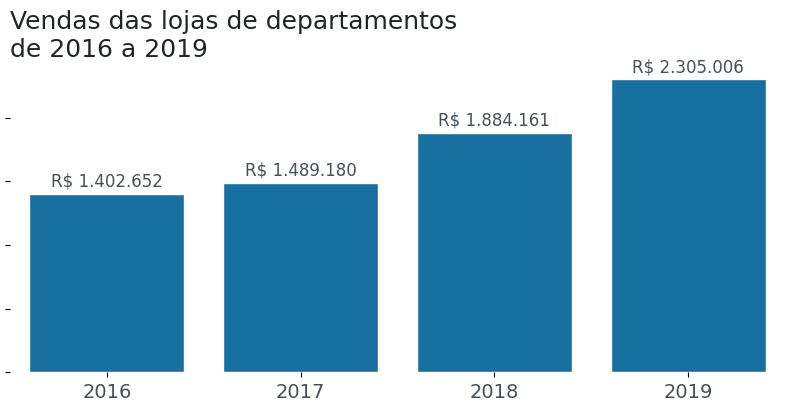

In [7]:
## Gerando a função para criar o gráfico de colunas

def grafico_vendas(cores: list=[AZUL2]):
  # Importando as bibliotecas
  import matplotlib.pyplot as plt
  import seaborn as sns

  # Área do gráfico e tema da visualização
  fig, ax = plt.subplots(figsize=(10,4))
  sns.set_theme(style="white")

  # Gerando o gráfico de colunas
  ax = sns.barplot(data = df_vendas_ano, y='vendas', x = df_vendas_ano.index, palette = cores)

  # Personalizando o gráfico
  ax.set_title("Vendas das lojas de departamentos\nde 2016 a 2019", loc="left", fontsize=18, color= CINZA1)
  ax.set_xlabel("")
  ax.set_ylabel("")
  ax.xaxis.set_tick_params(labelsize = 14, labelcolor = CINZA2)
  sns.despine(left= True, bottom = True)

  # Escrevendo os valores de cada barra no gráfico
  ax.set_yticklabels([])
  for i, valor in enumerate(df_vendas_ano["vendas"]):
    qtd = f'R$ {valor:,.0f}'.replace(",",".")
    offset = 1e5
    ax.text(i, valor + offset, qtd, color = CINZA2, fontsize =12, ha = "center", va = "center")

  # retornando o eixo
  return ax
ax = grafico_vendas()

<ipython-input-7-53104b922f96>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data = df_vendas_ano, y='vendas', x = df_vendas_ano.index, palette = cores)


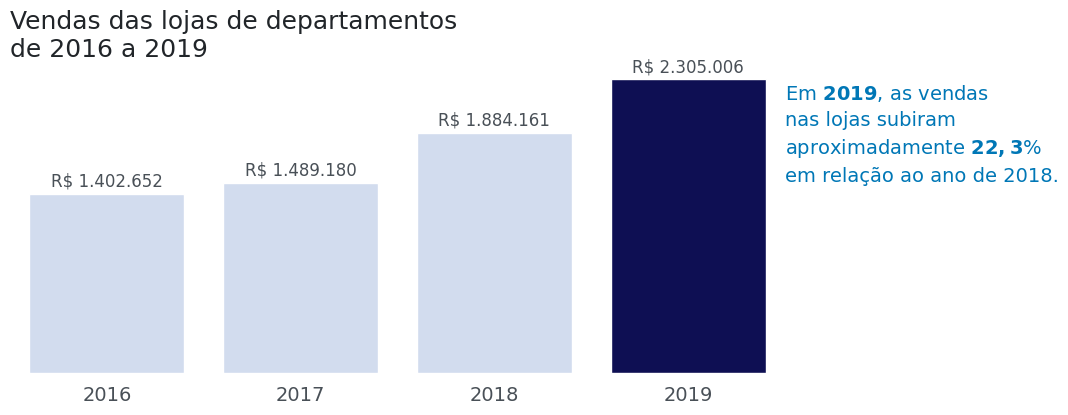

In [8]:
### Destaque por cor
cores = []
for ano in df_vendas_ano.index:
  if df_vendas_ano.loc[ano, 'vendas'] == df_vendas_ano['vendas'].max():
    cores.append(AZUL1)
  else:
    cores.append(AZUL5)
ax = grafico_vendas(cores)

ax.text(3.5,1.5e6,
        'Em $\\bf2019$, as vendas\n'
        'nas lojas subiram\n'
        'aproximadamente $\\bf{22,3}$%\n'
        'em relação ao ano de 2018.',
        fontsize=14, linespacing=1.45, color=AZUL2
)

fig = ax.get_figure()


# Gráficos de Barras

In [9]:
top_lucro = vendas.copy()

In [10]:
top_lucro = top_lucro[['tipo_produto','lucro']]
top_lucro = top_lucro.groupby('tipo_produto').sum()
top_lucro.sort_values(by='lucro', ascending=False, inplace=True)
top_7 = top_lucro[:7]
top_7

,lucro
tipo_produto,
peças de reposição,91148.67
pneus,67460.05
ferramentas automotivas,63330.22
pesticidas,53343.89
ferramentas de jardinagem,53202.88
ferramentas,41020.34
vasos,33941.85


<ipython-input-11-4fd149392588>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data = top_7, x="lucro", y = top_7.index, palette = cores)


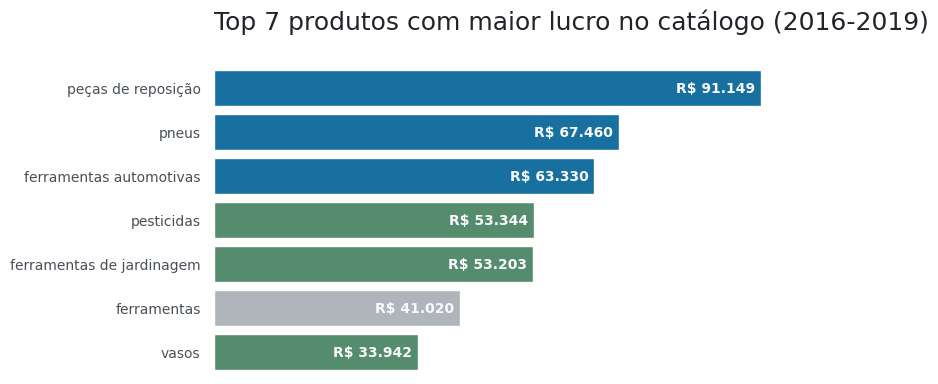

In [11]:
## Gerando a função para criar o gráfico de barras

def grafico_top_7():
  # Importando as bibliotecas
  import matplotlib.pyplot as plt
  import seaborn as sns

  # Área do gráfico e tema da visualização
  fig, ax = plt.subplots(figsize=(10,4))
  fig.subplots_adjust(right=0.7)
  sns.set_theme(style="white")

  # Definindo as cores do gráfico
  cores = [AZUL2, AZUL2, AZUL2, VERDE1, VERDE1, CINZA3, VERDE1]

  # Gerando o gráfico de barras
  ax = sns.barplot(data = top_7, x="lucro", y = top_7.index, palette = cores)

  # Personalizando o gráfico
  ax.set_title('Top 7 produtos com maior lucro no catálogo (2016-2019)\n', fontsize=18, color=CINZA1, loc='left')
  ax.set_xlabel('')
  ax.set_ylabel('')
  ax.set_xticklabels([])
  ax.yaxis.set_tick_params(labelsize=10, labelcolor = CINZA2)
  sns.despine(left = True, bottom = True)

    # Escrevendo os valores de cada barra no gráfico
  for i, valor in enumerate(top_7['lucro']):
      qtd = f'R$ {valor:,.0f}'.replace(',','.')
      offset = 1e3  # offset de 1.000
      ax.text(valor - offset, i, qtd, color= CINZA5, fontsize=10, fontweight='bold', ha='right', va='center')

  return ax

ax = grafico_top_7()

In [12]:
from matplotlib import transforms

def texto_colorido(x, y, texto, cores, esp=20, ax=None, **kw):
    cores = list(reversed(cores))
    t = ax.transData
    canvas = ax.figure.canvas

    for i, linha in enumerate(reversed(texto.split('\n'))):
        frases = linha.split('||')
        for s, cor in zip(frases, cores[i]):
            texto = ax.text(x, y, s, color=cor, transform=t, **kw)
            texto.draw(canvas.get_renderer())
            ex = texto.get_window_extent()
            t = transforms.offset_copy(texto._transform, x=ex.width,
                                       units='dots')

        t = transforms.offset_copy(ax.transData, x=0, y=(i + 1) * esp, units='dots')


<ipython-input-11-4fd149392588>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data = top_7, x="lucro", y = top_7.index, palette = cores)


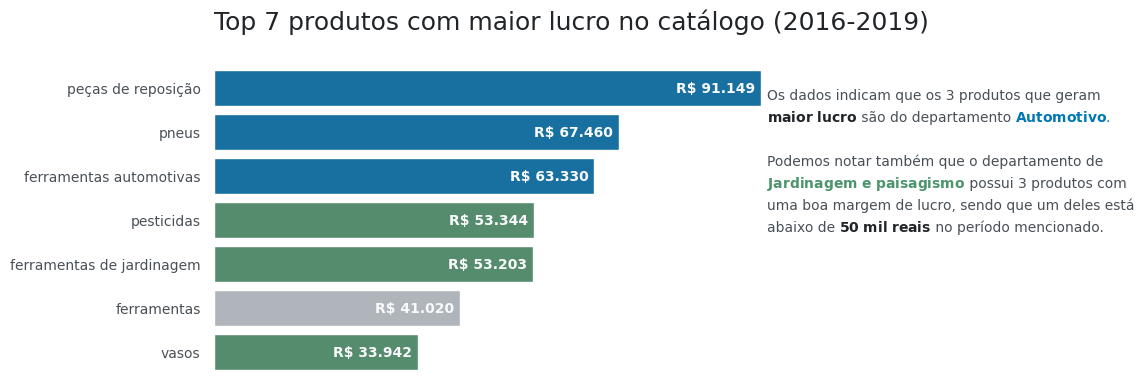

In [13]:
## Configurando o gráfico com parâmetros que potencializam a visualização dos dados

# Chamando a função do gráfico de barras
ax = grafico_top_7()

# Anotando uma conclusão no gráfico
texto_colorido(
    9.2e4, 3.25,                                                       			 # coordenadas
    'Os dados indicam que os 3 produtos que geram\n'                    # texto
    '$\\bf{maior\ lucro}$|| são do departamento ||$\\bf{Automotivo}$.\n'
    '\n'
    'Podemos notar também que o departamento de\n'
    '$\\bf{Jardinagem\ e\ paisagismo}$|| possui 3 produtos com\n'
    'uma boa margem de lucro, sendo que um deles está\n'
    'abaixo de ||$\\bf{50\ mil\ reais}$|| no período mencionado.',
    [[CINZA2],                       	           # linha 1                         		 # cores
     [CINZA1, CINZA2, AZUL2],         # linha 2
     [CINZA2],                                     # linha 3
     [CINZA2],                       	          # linha 4
     [VERDE1, CINZA2],                   # linha 5
     [CINZA2],                                    # linha 6
     [CINZA2, CINZA1, CINZA2]        # linha 7
    ],
    esp=22,				 # espaçamento
    ax=ax,				 # figura onde desenhar o texto
    fontsize=10)

fig = ax.get_figure()

### Desafio 1 - AULA 1
* Desafio 1: Quais são os lucros das vendas por ano? Em qual ano obtivemos o maior lucro?

* Desafio 2: Qual foi o faturamento (vendas) dos top 10 produtos durante o período de 2016 a 2019 do nosso conjunto de dados? Adicione um pequeno texto falando dos 3 produtos que mais venderam.

In [14]:
AZUL1, AZUL2, AZUL3, AZUL4, AZUL5 = '#03045e', '#0077b6', "#00b4d8", '#90e0ef', '#CDDBF3'
CINZA1, CINZA2, CINZA3, CINZA4, CINZA5 = '#212529', '#495057', '#adb5bd', '#dee2e6', '#f8f9fa'
VERMELHO1, LARANJA1, AMARELO1, VERDE1, VERDE2 = '#e76f51', '#f4a261',	'#e9c46a', '#4c956c', '#2a9d8f'

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [16]:
# Importando as bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importando o relatório de vendas e atualizando a colunas de pedido para o tipo data
vendas = pd.read_csv("https://raw.githubusercontent.com/alura-cursos/dataviz-graficos/master/dados/relatorio_vendas.csv")
vendas["data_pedido"] = pd.to_datetime(vendas["data_pedido"], format="%Y-%m-%d")

# Criando um df com os dados desejados
df_lucro_ano = vendas.copy()
df_lucro_ano = df_lucro_ano[["data_pedido", "lucro"]]

# Gerando uma coluna que represente apenas os anos puxando-os da coluna data pedido
df_lucro_ano["ano"] = df_lucro_ano.data_pedido.dt.year
df_lucro_ano.drop(labels = "data_pedido", axis = 1, inplace=True)

# Agrupando os dados por ano
df_lucro_ano = df_lucro_ano.groupby(["ano"]).aggregate("sum")

df_lucro_ano

,lucro
ano,
2016,75033.63
2017,101265.15
2018,129862.44
2019,148097.30


<ipython-input-17-da5e4ca8e934>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data = df_lucro_ano, x = df_lucro_ano.index, y="lucro", palette = cores)


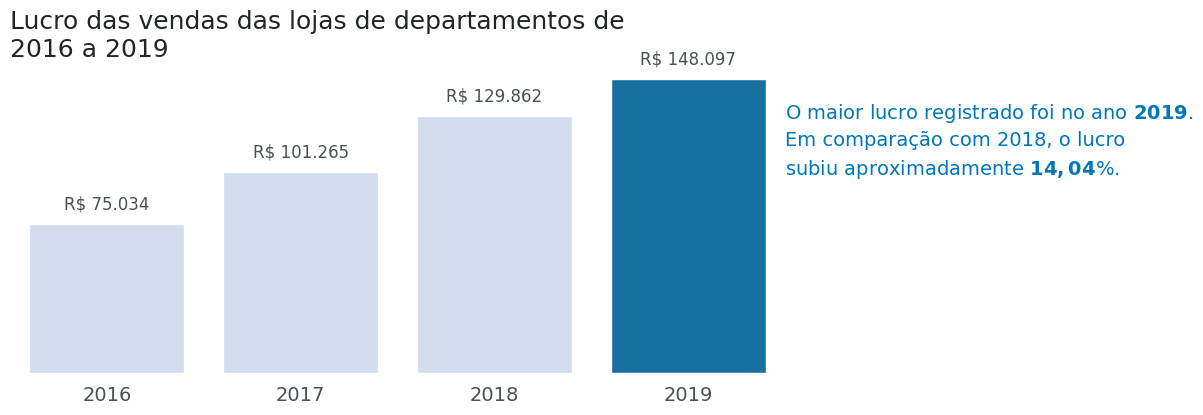

In [17]:
# Área do gráfico e tema da visualização
fig, ax = plt.subplots(figsize=(10,4))
sns.set_theme(style="white")

# Definindo as cores do gráfico
cores = []
for ano in df_lucro_ano.index:
  if df_lucro_ano.loc[ano,"lucro"] == df_lucro_ano["lucro"].max():
    cores.append(AZUL2)
  else:
    cores.append(AZUL5)

# Gerando o gráfico de colunas
ax = sns.barplot(data = df_lucro_ano, x = df_lucro_ano.index, y="lucro", palette = cores)

# Personalizando o gráfico
ax.set_title("Lucro das vendas das lojas de departamentos de\n2016 a 2019", loc="left", fontsize = 18, color = CINZA1)
ax.set_xlabel("")
ax.set_ylabel("")
ax.xaxis.set_tick_params(labelsize = 14, labelcolor= CINZA2)
sns.despine(left= True, bottom = True)

# Escrevendo os valores de cada barra no gráfico
ax.set_yticklabels([])
for i, valor in enumerate(df_lucro_ano["lucro"]):
  qtd = f'R$ {valor:,.0f}'.replace(",",".")
  offset = 1e4
  ax.text(i, valor + offset, qtd, color = CINZA2, fontsize = 12, ha = "center", va = "center")

# Anotando uma conclusão no gráfico
ax.text(3.5, 1e5,
         'O maior lucro registrado foi no ano $\\bf{2019}$.\n'
         'Em comparação com 2018, o lucro\n'
         'subiu aproximadamente $\\bf{14,04}$%.',
         fontsize=14, linespacing=1.45, color=AZUL2)

# Exibindo o gráfico
plt.show()

In [18]:
fat_produto = vendas.copy()
fat_produto = fat_produto[["tipo_produto", "vendas"]]

# Agrupando os dados por tipo_produto, ordenando de maneira decrescente pelas vendas e selecionando os 10 primeiros
fat_produto = fat_produto.groupby(["tipo_produto"]).agg("sum").sort_values("vendas", ascending = False)
top_10 = fat_produto[:10]
top_10

,vendas
tipo_produto,
pneus,1022428.97
ferramentas,995158.41
vasos,696044.18
ferramentas de jardinagem,648879.72
materiais de revestimento,629656.36
equipamentos de limpeza,542304.58
ferramentas automotivas,502109.29
peças de reposição,486907.94
encanamentos,373223.88


In [19]:
# Código para gerar o texto colorido

from matplotlib import transforms

def texto_colorido(x, y, texto, cores, esp=20, ax=None, **kw):
    cores = list(reversed(cores))
    t = ax.transData
    canvas = ax.figure.canvas

    for i, linha in enumerate(reversed(texto.split('\n'))):
        frases = linha.split('||')
        for s, cor in zip(frases, cores[i]):
            texto = ax.text(x, y, s, color=cor, transform=t, **kw)
            texto.draw(canvas.get_renderer())
            ex = texto.get_window_extent()
            t = transforms.offset_copy(texto._transform, x=ex.width,
                                       units='dots')

        t = transforms.offset_copy(ax.transData, x=0, y=(i + 1) * esp, units='dots')

<ipython-input-20-b67d7abd60b4>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data = top_10, x="vendas", y = top_10.index, palette = cores)


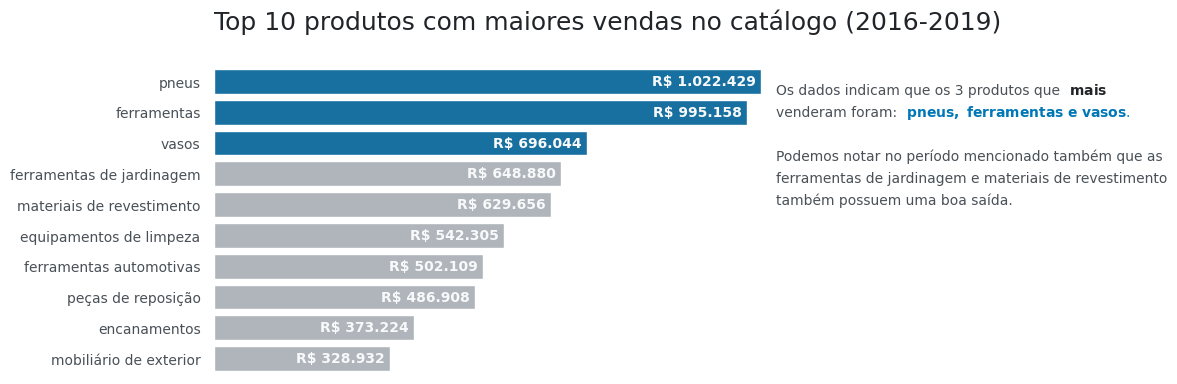

In [20]:
# Área do gráfico e tema da visualização
fig, ax = plt.subplots(figsize=(10,4))
fig.subplots_adjust(right=0.7)
sns.set_theme(style="white")

# Definindo as cores do gráfico: 3 primeiro em azul e restante em cinza
cores = [AZUL2 if i < 3 else CINZA3 for i in range(10)]

# Gerando o gráfico de barras
ax = sns.barplot(data = top_10, x="vendas", y = top_10.index, palette = cores)

# Personalizando o gráfico
ax.set_title('Top 10 produtos com maiores vendas no catálogo (2016-2019)\n', fontsize=18, color=CINZA1, loc='left')
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels([])
ax.yaxis.set_tick_params(labelsize=10, labelcolor = CINZA2)
sns.despine(left = True, bottom = True)

# Escrevendo os valores de cada barra no gráfico
for i, valor in enumerate(top_10['vendas']):
    qtd = f'R$ {valor:,.0f}'.replace(',','.')
    offset = 1e4  # offset de 10.000
    ax.text(valor - offset, i, qtd, color= CINZA5, fontsize=10, fontweight='bold', ha='right', va='center')

# Gerando o texto colorido
texto_colorido(
    1.05e6, 4,                                                      # coordenadas
    'Os dados indicam que os 3 produtos que || $\\bf{mais}$\n'     # texto
    'venderam foram: || $\\bf{pneus,\ ferramentas\ e\ vasos}$.\n'
    '\n'
    'Podemos notar no período mencionado também que as\n'
    'ferramentas de jardinagem e materiais de revestimento\n'
    'também possuem uma boa saída.',
    [[CINZA2, CINZA1],                # linha 1                     # cores
     [CINZA2, AZUL2],                 # linha 2
     [CINZA2],                        # linha 3
     [CINZA2],                        # linha 4
     [CINZA2],                        # linha 6
     [CINZA2]
    ],
    esp=22,         # espaçamento
    ax=ax,          # figura onde desenhar o texto
    fontsize=10)

# Exibindo o gráfico
plt.show()

### AULA 2 - GRAFICOS DE COLUNAS EMPILHADAS

In [21]:
df_vendas_reg = vendas.copy()
df_vendas_reg = df_vendas_reg[["regiao", "vendas","data_pedido"]]
df_vendas_reg['ano'] = df_vendas_reg.data_pedido.dt.year
df_vendas_reg.drop(labels="data_pedido", axis=1, inplace=True)
df_vendas_reg

,regiao,vendas,ano
0,Sudeste,890.66,2018
1,Sudeste,2488.59,2018
2,Sudeste,49.72,2018
3,Sul,3255.75,2017
4,Sul,76.04,2017
...,...,...,...
8935,Sudeste,123.22,2018
8936,Nordeste,271.97,2019
8937,Nordeste,700.75,2019
8938,Nordeste,85.83,2016


In [22]:
vendas_reg = pd.crosstab(index = df_vendas_reg.ano, columns = df_vendas_reg.regiao,
                         values = df_vendas_reg.vendas, aggfunc = "sum")
vendas_reg = vendas_reg[["Sudeste","Nordeste", "Centro-Oeste", "Sul", "Norte"]]
vendas_reg

regiao,Sudeste,Nordeste,Centro-Oeste,Sul,Norte
ano,,,,,
2016,739602.18,378521.83,121653.63,61294.12,101580.57
2017,803005.61,320804.28,149215.00,91990.16,124164.47
2018,1033836.21,401365.77,208068.71,132180.63,108710.09
2019,1146764.08,600738.87,257781.18,129410.82,170311.34


# Gerando o código

In [23]:
def grafico_vendas_regiao():
  # Definindo as cores do gráfico
  cores = [AZUL2, AZUL3, AZUL4, CINZA3, CINZA4]## Gerando a função para criar o gráfico de barras

  # Gerando o gráfico de colunas empilhadas
  # Using plt.gca() to get current axes
  fig, ax = plt.subplots(figsize=(10, 6))  # Explicitly create fig and ax
  vendas_reg.plot(kind="bar", stacked=True, ax=ax, color=cores)

  # Personalizando o gráfico
  ax.set_title('Vendas das lojas de departamentos por região\nde 2016 a 2019', loc='left', fontsize=22, color = CINZA1)
  ax.set_xlabel('')
  ax.set_ylabel('')
  ax.set_yticklabels([])
  ax.xaxis.set_tick_params(labelsize=14, labelcolor = CINZA2, rotation = 0)
  ax.set_frame_on(False)

  # remover todos os ticks do eixo x e y
  ax.tick_params(axis="both", which="both", length=0)

  # Anotando uma conclusão no gráfico
  ax.text(3.35, 1.1e6, '87%', fontweight='bold', fontsize=20, color=AZUL1)
  ax.text(3.35, 5.5e5,
          'das vendas nas lojas\n'
          'estão concentradas nas regiões\n'
          '$\\bf{Sudeste}$, $\\bf{Nordeste}$ e\n'
          '$\\bf{Centro-Oeste}$ em 2019.',
          fontsize=14,
          linespacing=1.45,
          color=AZUL1)

  return ax #Returning the axes object
  ax = grafico_vendas_regiao()

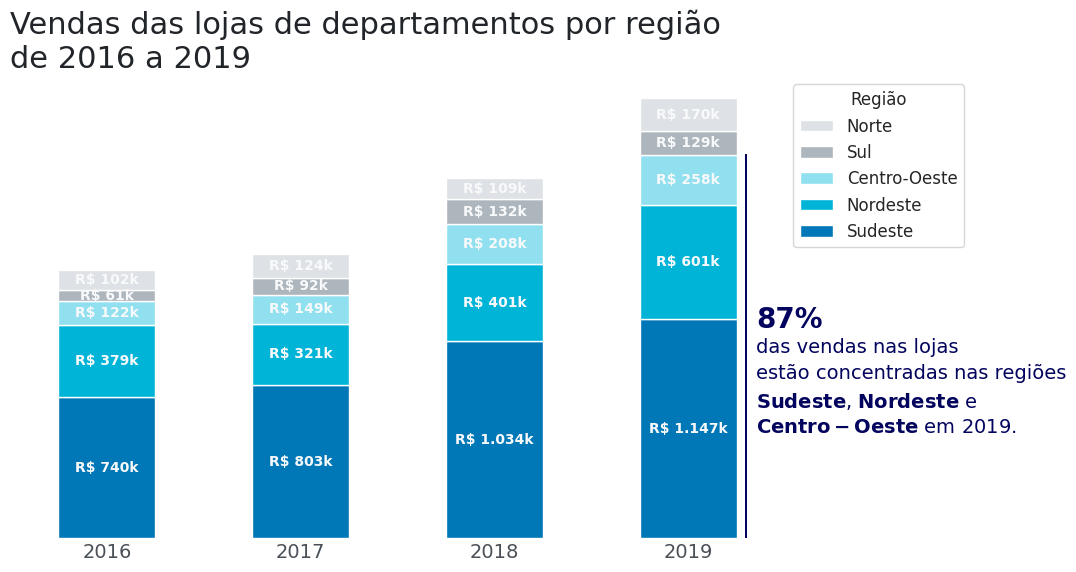

In [24]:
## Configurando o gráfico com parâmetros que potencializam a visualização dos dados

# Chamando a função do gráfico de barras
ax = grafico_vendas_regiao()

# Personalizando a legenda
ax.legend(bbox_to_anchor=(1,1), reverse = True, title = "Região", title_fontsize = 12, fontsize = 12)

# Adicionando os valores
for container in ax.containers:
  labels = [f'R$ {valor.get_height()/1000:,.0f}k'.replace(",",".") for valor in container]
  ax.bar_label(container, label_type="center", labels = labels, size = 10, color = CINZA5, fontweight = "bold")

  #Inserindo uma linha guia
  ax.axvline(x = 3.3, ymin=0, ymax = 0.83, color=AZUL1, linewidth=1.2)
fig = ax.get_figure()

### Gráfico de barras empilhadas

In [25]:
df_envio = vendas.copy()
df_envio = df_envio[["modo_envio", "segmento_cliente"]]

df_envio_seg = pd.crosstab(index = df_envio.modo_envio, columns = df_envio.segmento_cliente).sort_values("B2B")
df_envio_seg

segmento_cliente,B2B,B2C
modo_envio,,
24 horas,207,288
Envio rápido,676,673
Econômica,829,906
Entrega padrão,2552,2809


In [26]:
df_envio_normalizado = pd.crosstab(index = df_envio.modo_envio, columns = df_envio.segmento_cliente, normalize = "index")
df_envio_normalizado

segmento_cliente,B2B,B2C
modo_envio,,
24 horas,0.418182,0.581818
Econômica,0.477810,0.522190
Entrega padrão,0.476031,0.523969
Envio rápido,0.501112,0.498888


In [27]:
from matplotlib import transforms

def texto_colorido(x, y, texto, cores, esp=20, ax=None, **kw):
    cores = list(reversed(cores))
    t = ax.transData
    canvas = ax.figure.canvas

    for i, linha in enumerate(reversed(texto.split('\n'))):
        frases = linha.split('||')
        for s, cor in zip(frases, cores[i]):
            texto = ax.text(x, y, s, color=cor, transform=t, **kw)
            texto.draw(canvas.get_renderer())
            ex = texto.get_window_extent()
            t = transforms.offset_copy(texto._transform, x=ex.width,
                                       units='dots')

        t = transforms.offset_copy(ax.transData, x=0, y=(i + 1) * esp, units='dots')

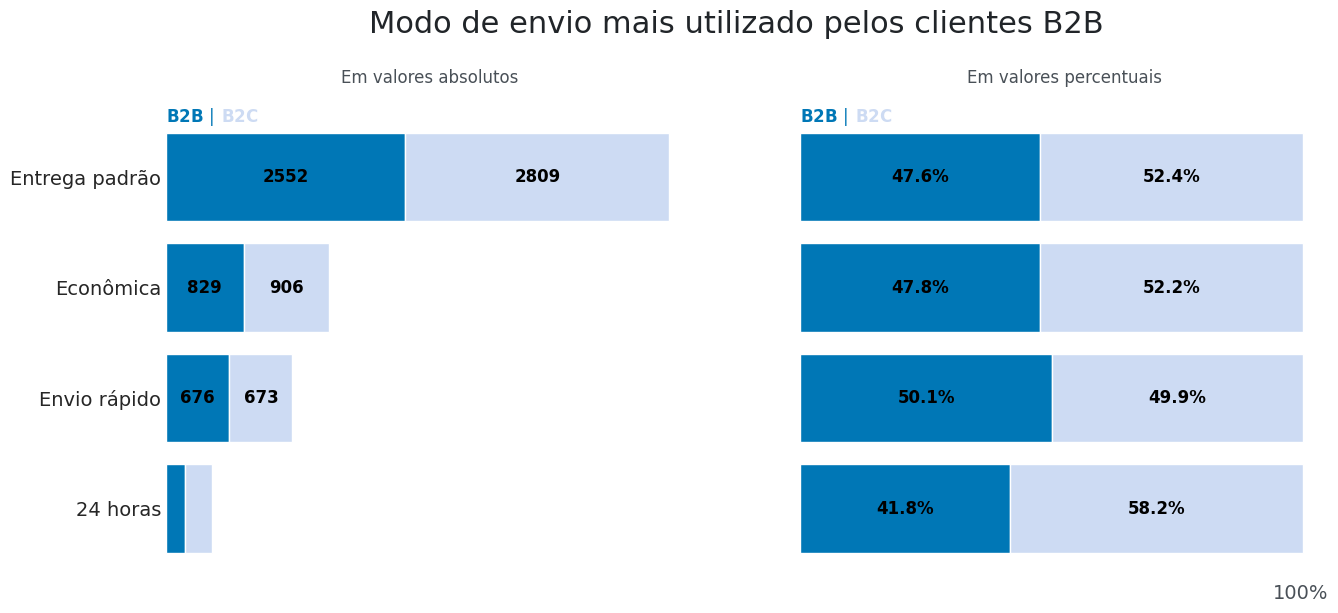

In [28]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1,2, figsize=(15,6), sharey=True)

cores = [AZUL2, AZUL5]

# GRÁFICO 1 - BARRAS EMPILHADAS
axs[0].barh(df_envio_seg.index, df_envio_seg["B2B"], color = cores[0])
axs[0].barh(df_envio_seg.index, df_envio_seg["B2C"], left= df_envio_seg["B2B"], color = cores[1])
axs[0].set_title('Em valores absolutos\n', color=CINZA2)
axs[0].set_xlabel('')
axs[0].set_ylabel('')
axs[0].set_xticklabels([])
axs[0].yaxis.set_tick_params(labelsize=14, color = CINZA2)
axs[0].set_frame_on(False)
axs[0].tick_params(axis="both", which="both", length=0)

texto_colorido(0, 3.5, '$\\bf{B2B}$ | || $\\bf{B2C}$', cores = [cores], ax=axs[0], fontsize=12)

# GRÁFICO 2 - BARRAS EMPILHADAS RELATIVAS
axs[1].barh(df_envio_normalizado.index, df_envio_normalizado["B2B"], color = cores[0])
axs[1].barh(df_envio_normalizado.index, df_envio_normalizado["B2C"], left= df_envio_normalizado["B2B"], color = cores[1])
axs[1].set_title('Em valores percentuais\n', color=CINZA2)
axs[1].set_xlabel('100%', color=CINZA2, size = 14, loc='right')
axs[1].set_ylabel('')
axs[1].set_xticklabels([])
axs[1].yaxis.set_tick_params(labelsize=14, color = CINZA2)
axs[1].set_frame_on(False)
axs[1].tick_params(axis="both", which="both", length=0)

texto_colorido(0, 3.5, '$\\bf{B2B}$ | || $\\bf{B2C}$', cores = [cores], ax=axs[1], fontsize=12)

fig.suptitle('Modo de envio mais utilizado pelos clientes B2B\n',
             fontsize=22, color=CINZA1, ha='right', x = 0.75, y = 1.05)

for container in axs[0].containers:
    labels = [str(valor.get_width()) if valor.get_width() > 300 else '' for valor in container]
    axs[0].bar_label(container, label_type='center', labels = labels, size = 12, color = 'black', fontweight='bold')

for container in axs[1].containers:
  labels = [f'{valor.get_width()*100:.1f}%' for valor in container]
  axs[1].bar_label(container, label_type="center", labels = labels, size = 12, color = 'black', fontweight = "bold")

fig.show()

### DESAFIO AULA 2

* Como estão divididas as vendas das lojas de departamentos na Região Centro-Oeste nos anos de 2017 e 2018? O mesmo estado permaneceu como o que mais vendeu nesta região?

* Analisando cada departamento, como estão divididos os modos de envio em cada um deles percentualmente?

In [29]:
# Importando as bibliotecas
import pandas as pd

# Importando o relatório de vendas e atualizando a colunas de pedido para o tipo data
vendas = pd.read_csv("https://raw.githubusercontent.com/alura-cursos/dataviz-graficos/master/dados/relatorio_vendas.csv")
vendas["data_pedido"] = pd.to_datetime(vendas["data_pedido"], format="%Y-%m-%d")

# Criando um df com os dados desejados
vendas_co = vendas.copy()
vendas_co = vendas_co[['data_pedido','regiao', 'estado', 'vendas']]

# Gerando uma coluna que represente apenas os anos puxando-os da coluna data pedido
vendas_co['ano'] = vendas_co.data_pedido.dt.year

# Selecionando apenas os dados do Centro-Oeste dos anos de 2017 e 2018 e removendo as colunas de data_pedido e região
vendas_co = vendas_co.query("regiao == 'Centro-Oeste' and (ano == 2017 or ano == 2018)")
vendas_co.drop(labels = ["data_pedido","regiao"], axis = 1, inplace = True)

vendas_co

,estado,vendas,ano
26,Distrito Federal,10483.69,2017
27,Distrito Federal,32.70,2017
28,Distrito Federal,422.28,2017
29,Distrito Federal,11.10,2017
30,Distrito Federal,293.40,2017
...,...,...,...
8737,Distrito Federal,421.35,2018
8833,Mato Grosso,289.20,2017
8884,Distrito Federal,114.00,2018
8885,Distrito Federal,124.92,2018


In [30]:
# Criando uma tabela cruzada (crosstab) com os valores de venda de cada ano por estado
vendas_co_ano = pd.crosstab(index = vendas_co.ano, columns = vendas_co.estado,
                         values = vendas_co.vendas, aggfunc = "sum")

vendas_co_ano

estado,Distrito Federal,Goiás,Mato Grosso,Mato Grosso do Sul
ano,,,,
2017,64308.70,66078.33,5259.46,13568.51
2018,103036.69,79801.93,10980.07,14250.02


In [31]:
from matplotlib import transforms

def texto_colorido(x, y, texto, cores, esp=20, ax=None, **kw):
    cores = list(reversed(cores))
    t = ax.transData
    canvas = ax.figure.canvas

    for i, linha in enumerate(reversed(texto.split('\n'))):
        frases = linha.split('||')
        for s, cor in zip(frases, cores[i]):
            texto = ax.text(x, y, s, color=cor, transform=t, **kw)
            texto.draw(canvas.get_renderer())
            ex = texto.get_window_extent()
            t = transforms.offset_copy(texto._transform, x=ex.width,
                                       units='dots')

        t = transforms.offset_copy(ax.transData, x=0, y=(i + 1) * esp, units='dots')

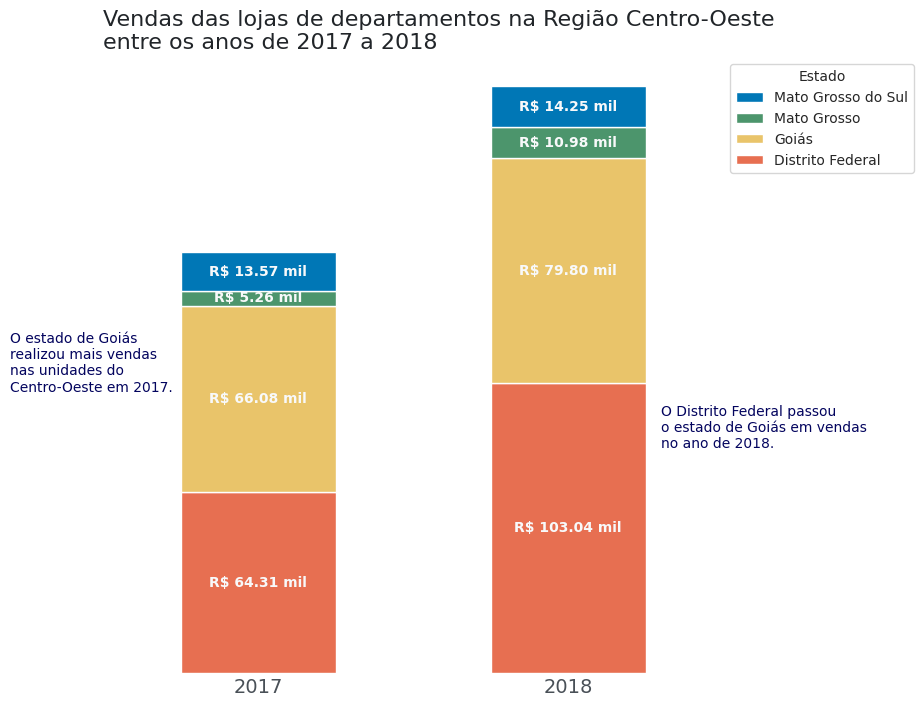

In [32]:
# Definindo as cores do gráfico
cores = [VERMELHO1, AMARELO1, VERDE1, AZUL2]

# Gerando o gráfico de colunas empilhadas
ax = vendas_co_ano.plot(kind="bar", stacked=True, figsize=(8,8), color = cores)

# Personalizando o gráfico
ax.set_title('Vendas das lojas de departamentos na Região Centro-Oeste\nentre os anos de 2017 a 2018',
             loc='left', fontsize=16, color = CINZA1)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_yticklabels([])
ax.xaxis.set_tick_params(labelsize=14, labelcolor = CINZA2, rotation = 0)
ax.set_frame_on(False)

# remover todos os ticks do eixo x e y
ax.tick_params(axis="both", which ="both", length=0)

# Anotando uma conclusão no gráfico
ax.text(-0.8, 1e5, 'O estado de Goiás\nrealizou mais vendas\nnas unidades do\nCentro-Oeste em 2017.',
        fontsize=10, linespacing=1.2, color=AZUL1)
ax.text(1.3, 8e4, 'O Distrito Federal passou\no estado de Goiás em vendas\nno ano de 2018.',
        fontsize=10, linespacing=1.2, color=AZUL1)

# Personalizando a legenda
ax.legend(bbox_to_anchor=(1,1), reverse = True, title= "Estado", title_fontsize = 10, fontsize = 10)

# Adicionando os valores
for container in ax.containers:
  labels = [f'R$ {valor.get_height()/1000:,.2f} mil'.replace(",",".") for valor in container]
  ax.bar_label(container, label_type="center", labels = labels, size = 10, color = CINZA5, fontweight = "bold")

fig = ax.get_figure()

In [33]:
# Importando as bibliotecas
import pandas as pd

# Importando o relatório de vendas
vendas = pd.read_csv("https://raw.githubusercontent.com/alura-cursos/dataviz-graficos/master/dados/relatorio_vendas.csv")

# Criando um df com os dados desejados
df_depart = vendas.copy()
df_depart = df_depart[['departamento','modo_envio']]

## Criando uma tabela cruzada (crosstab) com a frequência de modos de envio por departamento
df_depart = pd.crosstab(index = df_depart.departamento, columns = df_depart.modo_envio, normalize = "index")

df_depart

modo_envio,24 horas,Econômica,Entrega padrão,Envio rápido
departamento,,,,
Automotivo,0.051766,0.195493,0.593179,0.159562
Jardinagem e paisagismo,0.055504,0.190854,0.605569,0.148073
Materiais de construção,0.058133,0.202133,0.588267,0.151467


In [34]:
# Código para gerar o texto colorido

from matplotlib import transforms

def texto_colorido(x, y, texto, cores, esp=20, ax=None, **kw):
    cores = list(reversed(cores))
    t = ax.transData
    canvas = ax.figure.canvas

    for i, linha in enumerate(reversed(texto.split('\n'))):
        frases = linha.split('||')
        for s, cor in zip(frases, cores[i]):
            texto = ax.text(x, y, s, color=cor, transform=t, **kw)
            texto.draw(canvas.get_renderer())
            ex = texto.get_window_extent()
            t = transforms.offset_copy(texto._transform, x=ex.width,
                                       units='dots')

        t = transforms.offset_copy(ax.transData, x=0, y=(i + 1) * esp, units='dots')

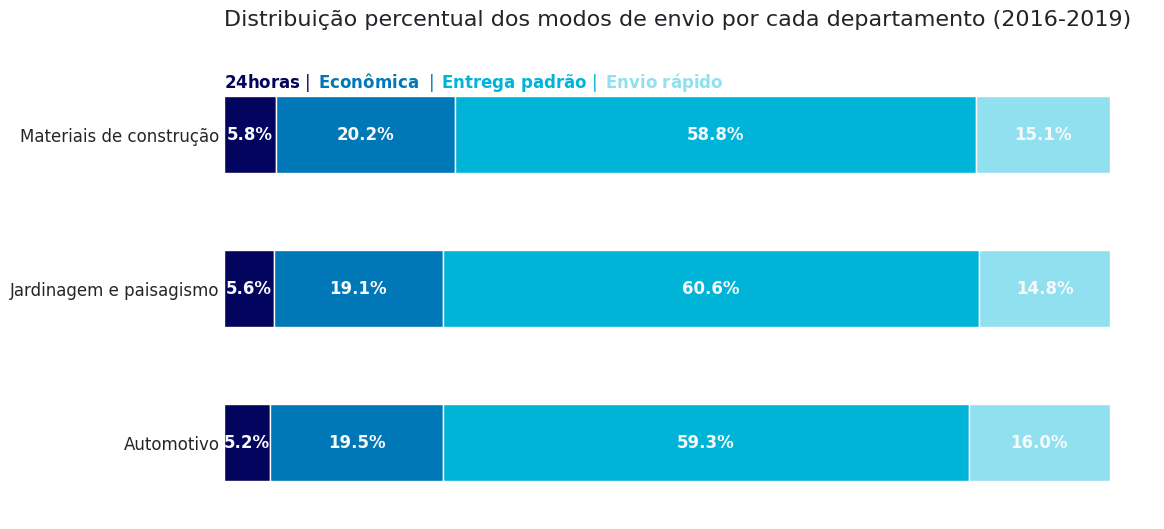

In [35]:
# Definindo as cores do gráfico
cores = [AZUL1, AZUL2, AZUL3, AZUL4]

# Gerando o gráfico de barras empilhadas
ax = df_depart.plot(kind="barh", stacked=True, figsize=(12,6), color = cores, legend = None)
ax.set_title("Distribuição percentual dos modos de envio por cada departamento (2016-2019)\n",
             fontsize=16, loc="left", color=CINZA1)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels([])
ax.yaxis.set_tick_params(labelsize=12, color = CINZA2)
ax.set_frame_on(False)

# remover todos os ticks do eixo x e y
ax.tick_params(axis='both', which='both', length=0)

# legenda dos dados
texto_colorido(0, 2.3, '$\\bf{24 horas}$ | || $\\bf{Econômica}$  | || $\\bf{Entrega\ padrão}$ | || $\\bf{Envio\ rápido}$', cores = [cores], ax=ax, fontsize=12)

# Valores das barras
for container in ax.containers:
    labels = [f'{valor.get_width()*100:.1f}%' for valor in container]
    ax.bar_label(container, label_type='center', labels = labels, size = 12, color = CINZA5, fontweight='bold')

fig = ax.get_figure()

# AULA 3 - Séries de tempo

In [36]:
df_sp = vendas.copy()
df_sp['data_pedido'] = pd.to_datetime(df_sp['data_pedido'])
df_sp = df_sp.query('estado == "São Paulo"')[['data_pedido', 'vendas']]
df_sp.set_index("data_pedido", inplace = True)
df_sp = df_sp.resample("Q").agg("sum")
df_sp['vendas'] = round(df_sp['vendas'] / 1e3, 2)
df_sp = df_sp.reset_index()
df_sp

<ipython-input-36-c9fb4fcfc52a>:5: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  df_sp = df_sp.resample("Q").agg("sum")


,data_pedido,vendas
0,2016-03-31,41.87
1,2016-06-30,43.79
2,2016-09-30,154.91
3,2016-12-31,144.82
4,2017-03-31,36.13
5,2017-06-30,76.86
6,2017-09-30,129.76
7,2017-12-31,197.94
8,2018-03-31,44.26
9,2018-06-30,109.64


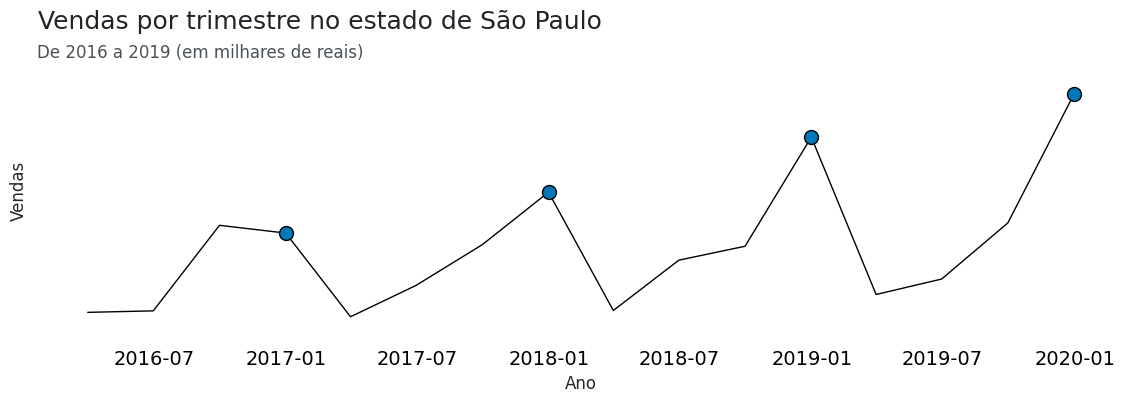

In [37]:
# prompt: Usando o DataFrame df_sp: line
def grafico_vendas_sp_tri():

  import matplotlib.pyplot as plt
  fig, ax = plt.subplots(figsize=(14,4))

  pontos_a_marcar = [True if mes == 12 else False for mes in df_sp['data_pedido'].dt.month]

  ax.plot(df_sp['data_pedido'], df_sp['vendas'], lw=1, color='black', marker = 'o',
          markersize = 10, markevery = pontos_a_marcar, markerfacecolor = AZUL2)

  ax.set_title('Vendas por trimestre no estado de São Paulo', fontsize = 18, color = CINZA1, loc='left')
  ax.text(0.3, 0.95, "De 2016 a 2019 (em milhares de reais)", transform=ax.transAxes, color= CINZA2, fontsize=12, ha='right', va='center')
  ax.set_xlabel('Ano')
  ax.set_ylabel('Vendas')
  ax.set_yticklabels([])
  ax.set_frame_on(False)
  ax.xaxis.set_tick_params(labelsize=14, labelcolor ='black')

  ax.tick_params(axis='both', which='both', length=0)

  plt.ylim(0, 400)

  return ax
ax = grafico_vendas_sp_tri()

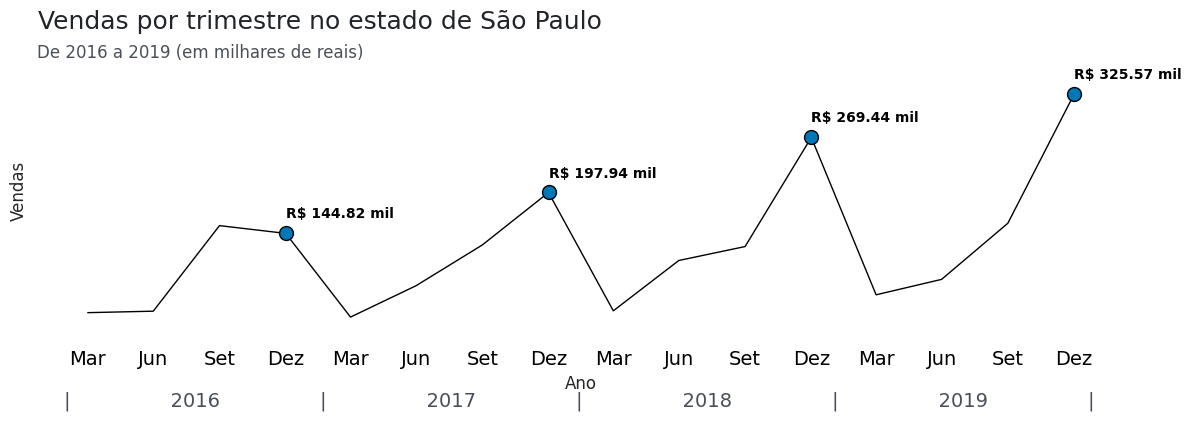

In [38]:
import matplotlib.dates as mdates #Realizava trataativa das variáveis de tempo

ax = grafico_vendas_sp_tri()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3)) # Define o formato a cada 3 meses
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
x_labels = ["Mar", "Jun", "Set", "Dez"] * 4 # Multiplica os meses pelo número de vezes que aparece no gráfico.
ax.set_xticks(df_sp.data_pedido)
ax.set_xticklabels(x_labels, ha='center')

texto = [16*" " + str(i) +16*" " for i in range(2016,2020)]
ax.text(ax.get_xbound()[0]+35, -80, f'|{texto[0]}|{texto[1]}|{texto[2]}|{texto[3]}|', fontsize=14, color=CINZA2) #Define a linha com os anos e sua posição.

ano = 0
for i in range(3, len(df_sp["vendas"]), 4):
  ax.text(x = ax.get_xticks()[i], y = df_sp["vendas"][i] + 20, s = f"R$ {df_sp['vendas'][i]} mil", color = 'black', weight = "bold", fontsize = 10)
 # ax.text(x = ax.get_xticks()[i] + 160, y = df_sp["vendas"][i] + 20, s = f"(4º Tri {2016 + ano})", color = CINZA2, weight = "bold", fontsize = 10)
  ano +=1

fig = ax.get_figure()


Exemplo de uso do Major locator, formater e etc..

In [39]:
# Importando as bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Importando o relatório de vendas e atualizando a colunas de pedido para o tipo data
vendas = pd.read_csv("https://raw.githubusercontent.com/alura-cursos/dataviz-graficos/master/dados/relatorio_vendas.csv")
vendas["data_pedido"] = pd.to_datetime(vendas["data_pedido"], format="%Y-%m-%d")

# Criando um df com os dados desejados
df_am = vendas.copy()
bienio = [2018, 2019]
df_am = df_am.query('estado == "Amazonas" and data_pedido.dt.year == @bienio')[["data_pedido", "vendas"]]

# Agrupando as vendas por início do mês (MS)
df_am.set_index("data_pedido", inplace = True)
df_am = df_am.resample("MS").agg("sum")
df_am = df_am.reset_index()
df_am.head()

,data_pedido,vendas
0,2018-01-01,532.16
1,2018-02-01,568.42
2,2018-03-01,8691.91
3,2018-04-01,712.42
4,2018-05-01,11791.93


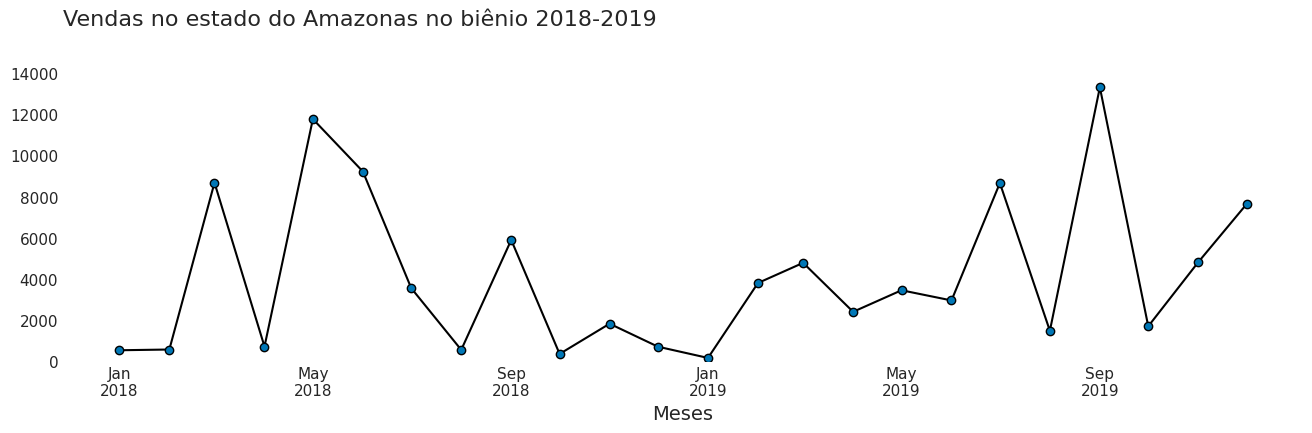

In [40]:
# Área do gráfico e tema da visualização
fig, ax = plt.subplots(figsize=(16,4))

# Criando o gráfico de linha das vendas pelo biênio 2018-2019
ax.plot(df_am["data_pedido"], df_am["vendas"], marker = "o", markerfacecolor = AZUL2,color="black")

## Personalizando o gráfico
ax.set_title('Vendas no estado do Amazonas no biênio 2018-2019', fontsize = 16, loc='left', pad = 20)
ax.set_xlabel('Meses', fontsize = 14)
ax.set_ylabel('')
ax.grid("")
ax.set_frame_on(False)

# remover todos os ticks do eixo x e y
ax.tick_params(axis='both', which='both', length=0)

# Descrevendo o limite mínimo e máximo do eixo y
plt.ylim(0, 15000)

# Definindo o intervalo de 4 em 4 meses (quadrimestre)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth = range(1,12,4)))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.set_xticks(ax.get_xticks()[:-1])   # retirando o último tick que não possui valores (Jan/2020)

plt.show()

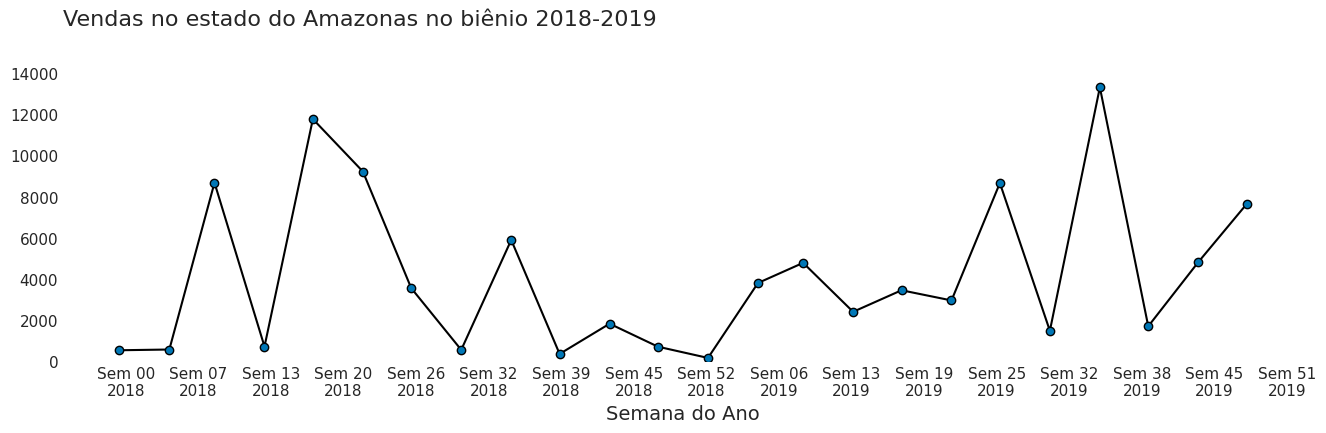

In [41]:
# Atualizando o gráfico para dados semanais
ax.set_xlabel('Semana do Ano', fontsize = 14)

# Definindo o intervalo em 45 dias e passando os valores de ticks como Semana e ano
ax.xaxis.set_major_locator(mdates.DayLocator(interval = 45))
ax.xaxis.set_major_formatter(mdates.DateFormatter("Sem %U\n%Y"))

ax.get_figure()

### Gráfico de Linhas

In [42]:
df_regiao = vendas.copy()
df_regiao = df_regiao[['regiao', 'vendas', 'data_pedido']]
df_regiao = pd.crosstab(index=df_regiao.data_pedido, columns=df_regiao.regiao, values = df_regiao.vendas, aggfunc='sum')
df_regiao = df_regiao[['Sudeste','Nordeste','Centro-Oeste','Norte','Sul']]
df_regiao

regiao,Sudeste,Nordeste,Centro-Oeste,Norte,Sul
data_pedido,,,,,
2016-01-04,55.92,NaN,NaN,NaN,NaN
2016-01-05,979.42,NaN,NaN,NaN,NaN
2016-01-06,NaN,NaN,66.42,NaN,NaN
2016-01-07,14940.66,43.44,NaN,NaN,NaN
2016-01-08,296.37,NaN,NaN,NaN,NaN
...,...,...,...,...,...
2019-12-27,NaN,2552.32,152.15,NaN,10.64
2019-12-28,603.96,NaN,NaN,NaN,NaN
2019-12-29,677.65,4079.73,NaN,456.94,NaN


In [43]:
df_regiao = df_regiao.resample('Q').agg('sum')
df_regiao = round(df_regiao/1e3,2)
df_regiao

<ipython-input-43-b957fc1384ee>:1: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  df_regiao = df_regiao.resample('Q').agg('sum')


regiao,Sudeste,Nordeste,Centro-Oeste,Norte,Sul
data_pedido,,,,,
2016-03-31,70.18,41.73,16.80,9.31,1.51
2016-06-30,122.72,87.41,30.83,24.68,10.62
2016-09-30,226.43,158.12,39.61,21.94,11.97
2016-12-31,320.27,91.27,34.41,45.65,37.19
2017-03-31,127.89,61.58,5.90,35.25,4.75
2017-06-30,161.54,54.93,16.96,13.35,21.23
2017-09-30,206.29,91.60,48.82,48.71,21.68
2017-12-31,307.28,112.69,77.54,26.86,44.34
2018-03-31,120.56,92.40,29.30,39.03,6.95


In [44]:
import plotly.express as px

fig = px.line(df_regiao, x=df_regiao.index, y=df_regiao.columns, markers = True, labels={"regiao": "Região"},
              color_discrete_sequence=[AZUL2, VERMELHO1, AMARELO1, VERDE1, CINZA3])

fig.update_layout(width=1300, height=600, font_family = 'DejaVu Sans', font_size=15,
                  font_color= CINZA2, title_font_color= CINZA1, title_font_size=24,
                   title_text='Faturamento da loja de departamentos por trimestre' +
                             '<br><sup size=1 style="color:55655">De 2016 a 2019</sup>',
                  xaxis_title='', yaxis_title='', plot_bgcolor= CINZA5)

fig.update_yaxes(tickprefix="R$ ", ticksuffix="mil") #Determina o prefixo e o sufixo dos valor no eixo Y.

labels = ['T1<br>2016', 'T2<br>2016', 'T3<br>2016', 'T4<br>2016',
           'T1<br>2017', 'T2<br>2017', 'T3<br>2017', 'T4<br>2017',
           'T1<br>2018', 'T2<br>2018', 'T3<br>2018', 'T4<br>2018',
           'T1<br>2019', 'T2<br>2019', 'T3<br>2019', 'T4<br>2019']
fig.update_xaxes(ticktext = labels, tickvals=df_regiao.index)

fig.show()

# Alterando texto informativo do gráfico

In [45]:
# Dados ao passar o mouse
fig.update_traces(mode="markers+lines", hovertemplate = "<b>Período<b> %{x} <br> <b>Faturamento<b> %{y}")
# fig.update_layout(hovermode="closest")    # para exibir apenas do dado que passamos o mouse
# fig.update_layout(hovermode="x")          # para exibir todos os dados do período em cada linha
fig.update_layout(hovermode="x unified")  # para exibir o resumo de todos os dados no período

fig.show()

### DESAFIO AULA 3

* 1: Como estão as vendas por semestre no estado em que você mora ou que deseja conhecer? Destaque os valores máximos e mínimos de venda para apresentá-los ao seu público.


* 2: Compare os lucros anuais dos estados da região Nordeste por meio de um gráfico de linhas.

In [46]:
# 1 - São Paulo
df_estado = vendas.copy()
df_estado = df_estado.query('estado == "São Paulo"')[["data_pedido", "vendas"]]
df_estado.set_index("data_pedido", inplace = True)
df_estado = df_estado.resample("6M", closed='left').agg("sum")
df_estado = round(df_estado/1e3,2)
df_estado = df_estado.reset_index()
df_estado

<ipython-input-46-432cc0be7d11>:5: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



,data_pedido,vendas
0,2016-06-30,85.61
1,2016-12-31,297.03
2,2017-06-30,114.34
3,2017-12-31,329.10
4,2018-06-30,153.90
5,2018-12-31,397.17
6,2019-06-30,143.41
7,2019-12-31,488.65
8,2020-06-30,1.71


In [47]:
import plotly.express as px

# Criando o gráfico de linha
fig = px.line(df_estado, x=df_estado.index, y=df_estado.vendas, markers=True, labels={"estado": "São Paulo"})

# Encontrando os valores máximo e mínimo
max_vendas = df_estado['vendas'].max()
min_vendas = df_estado['vendas'].min()
max_index = df_estado[df_estado['vendas'] == max_vendas].index[0]
min_index = df_estado[df_estado['vendas'] == min_vendas].index[0]

# Configuração do layout
fig.update_layout(
    width=1300, height=600, font_family='DejaVu Sans', font_size=15,
    font_color='black', title_font_color='black', title_font_size=24,
    title_text='Faturamento de São Paulo por Semestre' +
               '<br><sup size=1 style="color:55655">De 2016 a 2019</sup>',
    xaxis_title='', yaxis_title='', plot_bgcolor='white'
)

# Definição do formato do eixo Y
fig.update_yaxes(tickprefix="R$ ", ticksuffix=" mil", tickformat=".0f")  # Exibir valores inteiros sem abreviação

# Definição dos rótulos personalizados do eixo X
labels = ['S1<br>2016', 'S2<br>2016', 'S1<br>2017', 'S2<br>2017',
          'S1<br>2018', 'S2<br>2018', 'S1<br>2019', 'S2<br>2019']
fig.update_xaxes(ticktext=labels, tickvals=df_estado.index)

fig.add_hline(y=max_vendas, line_dash="dash", line_color="green", line_width=0.5, opacity=0.7)

# Adicionando linha tracejada para o valor mínimo
fig.add_hline(y=min_vendas, line_dash="dash", line_color="red", line_width=0.5, opacity=0.7)

# Criando textos de anotação dinâmicos
texto_max = (f"As vendas atingiram o recorde de R$ {max_vendas:,.0f} mil")
texto_min = (f"As vendas atingiram o menor valor de R$ {min_vendas:,.0f} mil")

# Adicionando a anotação para o valor máximo
fig.add_annotation(
    x=max_index, y=max_vendas,
    text=texto_max,
    showarrow=True, arrowhead=2, ax=0, ay=-50,
    font=dict(size=12, color="green"),
    bgcolor="white", bordercolor="green"
)

# Adicionando a anotação para o valor mínimo
fig.add_annotation(
    x=min_index, y=min_vendas,
    text=texto_min,
    showarrow=True, arrowhead=2, ax=0, ay=50,
    font=dict(size=12, color="red"),
    bgcolor="white", bordercolor="red"
)

# Exibindo o gráfico
fig.show()


In [48]:
# 1 - Sudeste
df_sudeste = vendas.copy()
df_sudeste = df_sudeste.query('regiao == "Sudeste"')[["data_pedido", "vendas", "estado", "lucro"]]
df_sudeste = pd.crosstab(index=df_sudeste.data_pedido, columns=df_sudeste.estado, values = df_sudeste.lucro, aggfunc='sum')
df_sudeste = df_sudeste.resample('Y').agg('sum')
f_sudeste = round(df_sudeste/1e3,2)
df_sudeste

<ipython-input-48-d2bb6ec4a123>:5: FutureWarning:

'Y' is deprecated and will be removed in a future version, please use 'YE' instead.



estado,Espírito Santo,Minas Gerais,Rio de Janeiro,São Paulo
data_pedido,,,,
2016-12-31,2870.10,-4495.74,14109.53,17924.71
2017-12-31,2920.97,3878.85,11335.87,37828.58
2018-12-31,10526.93,-15594.49,24038.24,66272.91
2019-12-31,-1742.29,-1983.36,26810.90,74680.96


In [49]:
# Importando a biblioteca
import plotly.express as px

# Gerando um gráfico de linha com os lucros das lojas por ano dividido por estado da região sudeste
fig = px.line(df_sudeste, x=df_sudeste.index, y=df_sudeste.columns, markers=True, labels={"estado": "Estados"},
              color_discrete_sequence=[AZUL2, VERMELHO1, AMARELO1 , VERDE1, CINZA3, AZUL5, LARANJA1, CINZA1, AZUL4])

# Ajustando o layout do gráfico
fig.update_layout(width=1300, height=600, font_family='DejaVu Sans', font_size=15,
                  font_color=CINZA2, title_font_color=CINZA1, title_font_size=24,
                  title_text='Lucros das lojas de departamentos por ano na Região Sudeste' +
                             '<br><sup size=1 style="color:#555655">De 2016 a 2019</sup>',
                  xaxis_title='', yaxis_title='', plot_bgcolor=CINZA5)

# Ajustando os ticks do eixo y para o formato em milhar
fig.update_yaxes(tickprefix="R$ ", ticksuffix=" mil")

# Ajustando o eixo x com os labels dos anos
labels = ['2016', '2017', '2018', '2019']
fig.update_xaxes(ticktext=labels, tickvals=df_sudeste.index)

# Dados ao passar o mouse (hover)
fig.update_traces(mode="markers+lines", hovertemplate="<b>Período:</b> %{x} <br> <b>Lucro:</b> %{y}")

fig.show()


### Aula 4 - Distribuindo Dados

1ª base:

* Como estão distribuídos os dados dos volumes da amostra do amaciante? Qual seria seu valor central (média e mediana).
* Como estão distribuídos os dados dos volumes do amaciante de acordo com a mediana e os quartis? Possuo dados discrepantes?

2ª base

* Como está a distribuição das medidas de comprimento da embalagem de sabão em pó para cada uma das amostras?
* Como estão dispostas as medidas de comprimento e altura da amostra A? Se quisermos rejeitar todos os itens em que o valor de comprimento e altura está 1% acima ou abaixo do valor de 20 cm e 15 cm respectivamente, quais seriam rejeitados?

In [50]:
base1 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Avançando em Data Science com Python/Dados/volume_amaciante.csv')
base2 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Avançando em Data Science com Python/Dados/medidas_sabao_em_po.csv')

# Pergunta 1

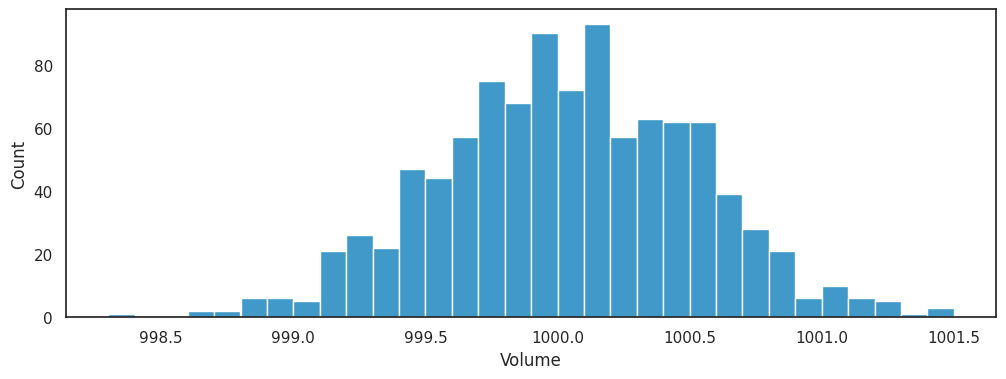

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

fig , ax = plt.subplots(figsize=(12,4))
sns.set_theme(style="ticks")

ax= sns.histplot(data = base1, x = "Volume", binwidth = 0.1, color = AZUL2)

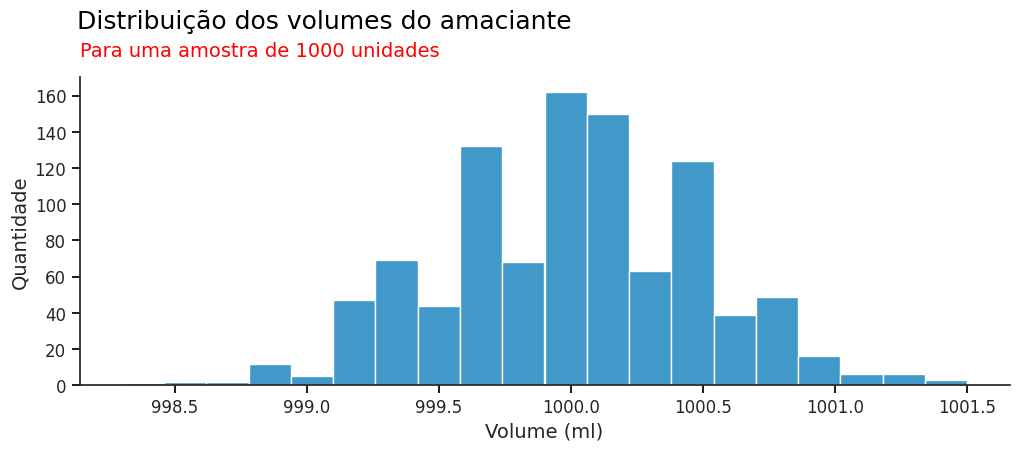

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

fig , ax = plt.subplots(figsize=(12,4))
sns.set_theme(style="ticks")

# ax= sns.histplot(data = base1, x = "Volume", binwidth = 0.1, color = AZUL2)
ax = sns.histplot(data=base1, x="Volume", bins=20, color=AZUL2)

plt.suptitle('Distribuição dos volumes do amaciante', size=18, color ='black', ha = 'right', x = 0.535, y = 1.05)
plt.title('Para uma amostra de 1000 unidades', fontsize = 14, color ='red', pad=15, loc='left')
ax.set_xlabel('Volume (ml)', fontsize = 14)
ax.set_ylabel('Quantidade', fontsize = 14)
ax.yaxis.set_tick_params(labelsize=12, color ='black')
ax.xaxis.set_tick_params(labelsize=12, color ='black')
sns.despine()

### Histogramas de linhas

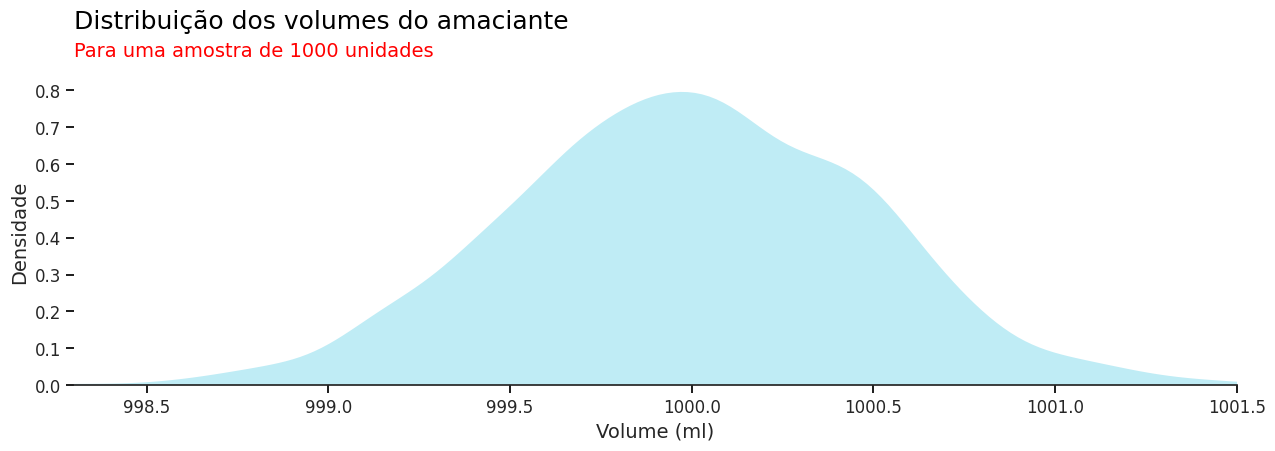

In [129]:
def grafico_densidade():
  import matplotlib.pyplot as plt
  import seaborn as sns

  fig , ax = plt.subplots(figsize=(15,4))
  sns.set_theme(style='ticks')

  ax = sns.kdeplot(data = base1, x = 'Volume', fill = True, color = AZUL3, lw=0)

  plt.suptitle('Distribuição dos volumes do amaciante', size=18, color ='black', ha = 'right', x = 0.455, y = 1.05)
  plt.title('Para uma amostra de 1000 unidades', fontsize = 14, color ='red', pad=15, loc='left')
  ax.set_xlabel('Volume (ml)', fontsize = 14)
  ax.set_ylabel('Densidade', fontsize = 14)
  ax.yaxis.set_tick_params(labelsize=12, color ='black')
  ax.xaxis.set_tick_params(labelsize=12, color ='black')
  ax.set_xlim(base1.Volume.min(), base1.Volume.max())
  sns.despine(left=True)

  return ax

ax = grafico_densidade()

# Adicionando a média e a mediana

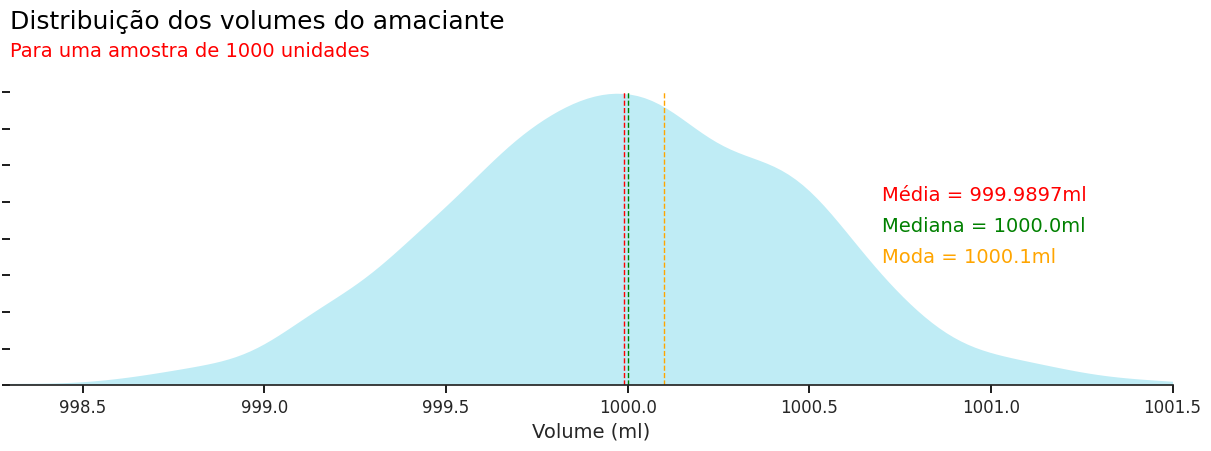

In [96]:
ax = grafico_densidade()

ax.set_ylabel('')
ax.set_yticklabels([])

estat = base1.Volume.mean(), base1.Volume.median(), base1.Volume.mode()[0]

desc = ['Média', 'Mediana', 'Moda']

Cores= ['red', 'green', 'orange']

ax.vlines(x=estat, ymin=0, ymax=0.8, colors=Cores, linestyles='--', lw=1) # inserindo as linhas no histograma.

for i in range(len(estat)):
  ax.text(0.75, (0.6 - i/10), f'{desc[i]} = {estat[i]}ml', fontsize = 14, color=Cores[i], transform=ax.transAxes)

fig = ax.get_figure()



# BOXPLOT

# Respondendo a pergunta 2 da base 1

In [77]:
# Importando as bibliotecas
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import seaborn as sns

In [101]:
Q1 = base1["Volume"].quantile(0.25)
Q3 = base1["Volume"].quantile(0.75)
IIQ = Q3 - Q1
limite_superior = base1["Volume"].quantile(0.75) + 1.5 * IIQ
limite_inferior = base1["Volume"].quantile(0.25) - 1.5 * IIQ
print(f"Limite superior = {limite_superior}", f"\nLimite inferior = {limite_inferior}")

Limite superior = 1001.1999999999998 
Limite inferior = 998.8000000000002


/usr/local/lib/python3.10/dist-packages/matplotlib/text.py:1463: FutureWarning:

Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead



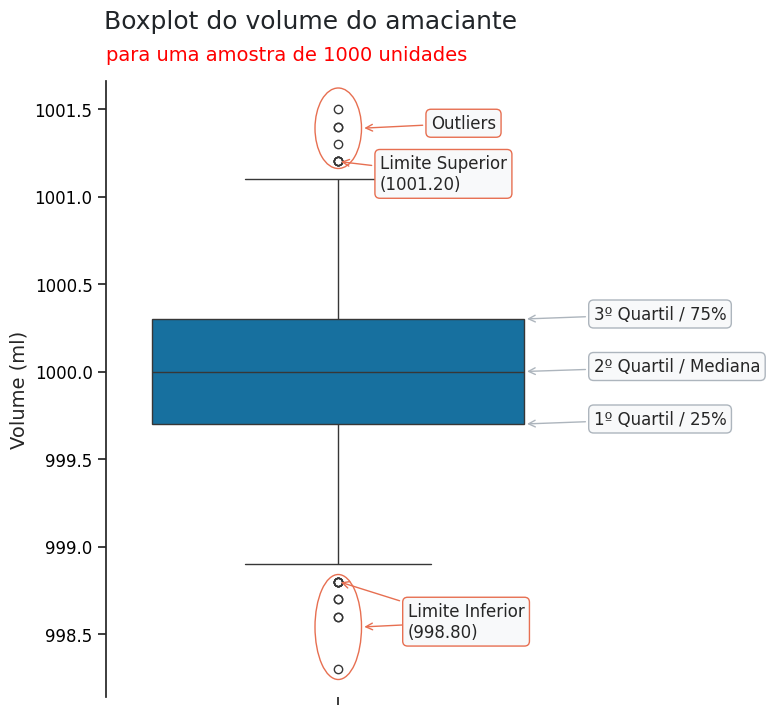

In [128]:
# Área do gráfico e tema da visualização
fig, ax = plt.subplots(figsize=(6,8))
sns.set_theme(style="ticks")

# Gerando o boxplot
ax = sns.boxplot(data = base1, y = "Volume", orient = "v", color = AZUL2)

# Personalizando o gráfico
plt.suptitle('Boxplot do volume do amaciante', size=18, color=CINZA1, ha = 'right', x = 0.81, y = 0.97)
plt.title('para uma amostra de 1000 unidades', fontsize=14, color='red', pad = 15, loc = "left")
ax.set_xlabel('')
ax.set_ylabel('Volume (ml)', fontsize = 14)
ax.yaxis.set_tick_params(labelsize=12, labelcolor = 'black')
sns.despine(bottom=True)

# Gerando outros elementos visuais (elipses dos outliers)
y_min, y_max = ax.get_ybound()
outlier_sup = Ellipse((0, y_max - 0.27), width = 0.1, height = 0.46, color=VERMELHO1, fill=False) # Cria círculos demarcando os outliers
outlier_inf = Ellipse((0, y_min + 0.4), width = 0.1, height = 0.6, color=VERMELHO1, fill=False) # Cria círculos demarcando os outliers
ax.add_patch(outlier_sup) # adiciona as elipes no gráfico
ax.add_patch(outlier_inf) # adiciona as elipes no gráfico

# Adicionando a explicação dos elementos de um boxplot
# O anotate consegue incluir setas  no gráfico c, por exemplo
ax.annotate("Outliers", xy=(0 + 0.05, y_max - 0.27), xycoords='data',    # coordenadas do ponto desejado
            bbox=dict(boxstyle="round", fc=CINZA5, ec=VERMELHO1),         # caixa de texto
            xytext=(50, 0), textcoords='offset points',                   # posição do texto
            arrowprops=dict(arrowstyle="->", color=VERMELHO1))            # propriedades da seta

ax.annotate("Outliers", xy=(0 + 0.05, y_min + 0.4), xycoords='data',
            bbox=dict(boxstyle="round", fc=CINZA5, ec=VERMELHO1),
            xytext=(50, 0), textcoords='offset points',
            arrowprops=dict(arrowstyle="->", color=VERMELHO1))

ax.annotate("1º Quartil / 25%", xy=(0.4, base1.quantile(.25)), xycoords='data', # o quantile relaciona o quartil com o valor dos vados
            bbox=dict(boxstyle="round", fc=CINZA5, ec=CINZA3),
            xytext=(50, 0), textcoords='offset points',
            arrowprops=dict(arrowstyle="->", color=CINZA3))

ax.annotate("2º Quartil / Mediana", xy=(0.4, base1.median()), xycoords='data',
            bbox=dict(boxstyle="round", fc=CINZA5, ec=CINZA3),
            xytext=(50, 0), textcoords='offset points',
            arrowprops=dict(arrowstyle="->", color=CINZA3))

ax.annotate("3º Quartil / 75%", xy=(0.4, base1.quantile(.75)), xycoords='data',
            bbox=dict(boxstyle="round", fc=CINZA5, ec=CINZA3),
            xytext=(50, 0), textcoords='offset points',
            arrowprops=dict(arrowstyle="->", color=CINZA3))

# Anotação do Limite Superior
ax.annotate(f"Limite Superior\n({limite_superior:.2f})",
            xy=(0, limite_superior), xycoords='data',
            bbox=dict(boxstyle="round", fc=CINZA5, ec=VERMELHO1),
            xytext=(30, -20), textcoords='offset points',  # deslocamento do texto
            arrowprops=dict(arrowstyle="->", color=VERMELHO1))

# Anotação do Limite Inferior
ax.annotate(f"Limite Inferior\n({limite_inferior:.2f})",
            xy=(0, limite_inferior), xycoords='data',
            bbox=dict(boxstyle="round", fc=CINZA5, ec=VERMELHO1),
            xytext=(50, -40), textcoords='offset points',  # deslocamento do texto
            arrowprops=dict(arrowstyle="->", color=VERMELHO1))

plt.show()

### DESAFIO AULA 4

* 1- Baixe a base de dados com as amostras das idades dos moradores do município de Cidade Alegre e crie os histogramas de colunas e de linha lado a lado, buscando interpretar as diferenças entre eles e o que podem representar separadamente. Adicione também uma linha que define a mediana da distribuição no histograma de linha e escreva o valor dessa medida no gráfico.

* 2 - Represente no boxplot dos volumes do amaciante os limites superiores e inferiores do diagrama de caixa. Comente sobre o resultado encontrado ao desenhar esses limites no boxplot.

Desafio 1

In [122]:
pop_idade = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Avançando em Data Science com Python/Dados/pop_idade.csv')
pop_idade.head()

,idade
0,39
1,33
2,41
3,50
4,32


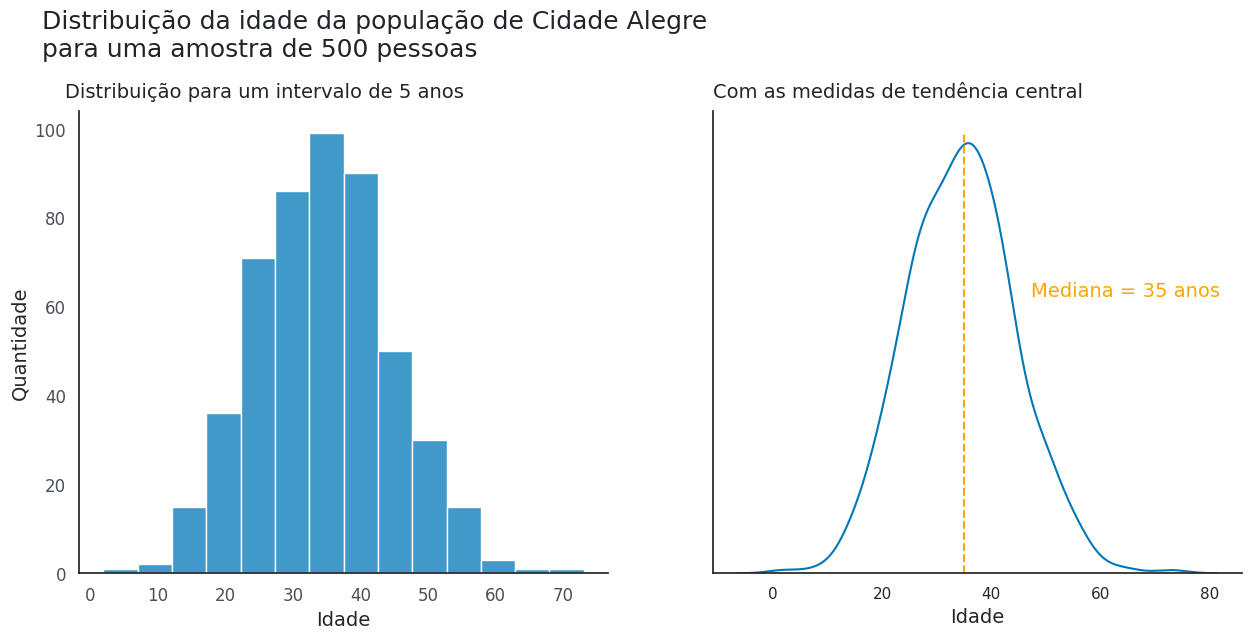

In [135]:
# Área do gráfico e tema da visualização
fig, axs = plt.subplots(1, 2, figsize=(15,6))
sns.set_theme(style="white")

# Título dos gráficos
fig.suptitle("Distribuição da idade da população de Cidade Alegre \npara uma amostra de 500 pessoas",
             fontsize=18, color=CINZA1, x = 0.1, y = 1.05, ha="left")

# GRÁFICO 1 - Histograma de Colunas

sns.histplot(ax = axs[0], data = pop_idade, x = "idade", binwidth = 5, color = AZUL2)
axs[0].set_title('Distribuição para um intervalo de 5 anos', size=14, color=CINZA1, x = 0.35,  pad = 10)
axs[0].set_xlabel('Idade', fontsize = 14)
axs[0].set_ylabel('Quantidade', fontsize = 14)
axs[0].yaxis.set_tick_params(labelsize=12, labelcolor = CINZA2)
axs[0].xaxis.set_tick_params(labelsize=12, labelcolor = CINZA2)
sns.despine()

# GRÁFICO 2 - Histograma de Linhas

sns.kdeplot(ax = axs[1], data = pop_idade, x = "idade", color = AZUL2)
axs[1].set_title('Com as medidas de tendência central', size=14, color=CINZA1, x = 0.35,  pad = 10)
axs[1].set_xlabel('Idade', fontsize = 14)
axs[1].set_ylabel('')
axs[1].yaxis.set_tick_params(labelsize=12, labelcolor = CINZA2)
axs[1].set_yticklabels([])
sns.despine()

# gerando a linha que define a mediana e anotando seu valor
axs[1].vlines(x = pop_idade.idade.median(), ymin = 0, ymax = 0.04, colors = 'orange', linestyles = "--")
axs[1].text(0.6, 0.6, f'Mediana = {int(pop_idade.idade.median())} anos', fontsize=14, color = 'orange', transform=axs[1].transAxes)

plt.show()

Desafio 2

/usr/local/lib/python3.10/dist-packages/matplotlib/text.py:1463: FutureWarning:

Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead



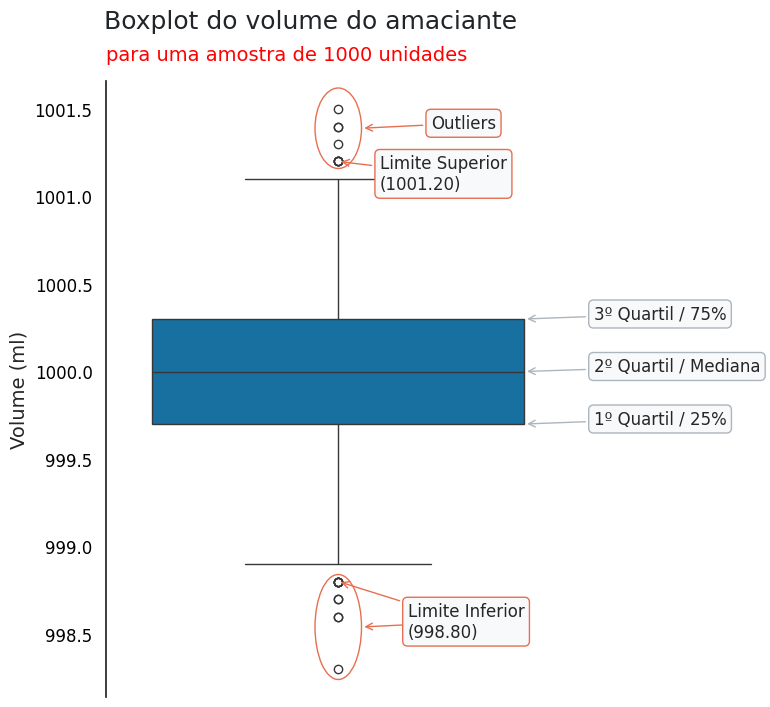

In [136]:
# Área do gráfico e tema da visualização
fig, ax = plt.subplots(figsize=(6,8))
sns.set_theme(style="ticks")

# Gerando o boxplot
ax = sns.boxplot(data = base1, y = "Volume", orient = "v", color = AZUL2)

# Personalizando o gráfico
plt.suptitle('Boxplot do volume do amaciante', size=18, color=CINZA1, ha = 'right', x = 0.81, y = 0.97)
plt.title('para uma amostra de 1000 unidades', fontsize=14, color='red', pad = 15, loc = "left")
ax.set_xlabel('')
ax.set_ylabel('Volume (ml)', fontsize = 14)
ax.yaxis.set_tick_params(labelsize=12, labelcolor = 'black')
sns.despine(bottom=True)

# Gerando outros elementos visuais (elipses dos outliers)
y_min, y_max = ax.get_ybound()
outlier_sup = Ellipse((0, y_max - 0.27), width = 0.1, height = 0.46, color=VERMELHO1, fill=False) # Cria círculos demarcando os outliers
outlier_inf = Ellipse((0, y_min + 0.4), width = 0.1, height = 0.6, color=VERMELHO1, fill=False) # Cria círculos demarcando os outliers
ax.add_patch(outlier_sup) # adiciona as elipes no gráfico
ax.add_patch(outlier_inf) # adiciona as elipes no gráfico

# Adicionando a explicação dos elementos de um boxplot
# O anotate consegue incluir setas  no gráfico c, por exemplo
ax.annotate("Outliers", xy=(0 + 0.05, y_max - 0.27), xycoords='data',    # coordenadas do ponto desejado
            bbox=dict(boxstyle="round", fc=CINZA5, ec=VERMELHO1),         # caixa de texto
            xytext=(50, 0), textcoords='offset points',                   # posição do texto
            arrowprops=dict(arrowstyle="->", color=VERMELHO1))            # propriedades da seta

ax.annotate("Outliers", xy=(0 + 0.05, y_min + 0.4), xycoords='data',
            bbox=dict(boxstyle="round", fc=CINZA5, ec=VERMELHO1),
            xytext=(50, 0), textcoords='offset points',
            arrowprops=dict(arrowstyle="->", color=VERMELHO1))

ax.annotate("1º Quartil / 25%", xy=(0.4, base1.quantile(.25)), xycoords='data', # o quantile relaciona o quartil com o valor dos vados
            bbox=dict(boxstyle="round", fc=CINZA5, ec=CINZA3),
            xytext=(50, 0), textcoords='offset points',
            arrowprops=dict(arrowstyle="->", color=CINZA3))

ax.annotate("2º Quartil / Mediana", xy=(0.4, base1.median()), xycoords='data',
            bbox=dict(boxstyle="round", fc=CINZA5, ec=CINZA3),
            xytext=(50, 0), textcoords='offset points',
            arrowprops=dict(arrowstyle="->", color=CINZA3))

ax.annotate("3º Quartil / 75%", xy=(0.4, base1.quantile(.75)), xycoords='data',
            bbox=dict(boxstyle="round", fc=CINZA5, ec=CINZA3),
            xytext=(50, 0), textcoords='offset points',
            arrowprops=dict(arrowstyle="->", color=CINZA3))

# Anotação do Limite Superior
ax.annotate(f"Limite Superior\n({limite_superior:.2f})",
            xy=(0, limite_superior), xycoords='data',
            bbox=dict(boxstyle="round", fc=CINZA5, ec=VERMELHO1),
            xytext=(30, -20), textcoords='offset points',  # deslocamento do texto
            arrowprops=dict(arrowstyle="->", color=VERMELHO1))

# Anotação do Limite Inferior
ax.annotate(f"Limite Inferior\n({limite_inferior:.2f})",
            xy=(0, limite_inferior), xycoords='data',
            bbox=dict(boxstyle="round", fc=CINZA5, ec=VERMELHO1),
            xytext=(50, -40), textcoords='offset points',  # deslocamento do texto
            arrowprops=dict(arrowstyle="->", color=VERMELHO1))

plt.show()

### NUVEM DE PALAVRAS

In [148]:
#import pandas as pd
#import numpy as np
#import matplotlib.pyplot as plt
#from wordcloud import WordCloud
#from PIL import Image

# Importando o relatório de vendas
#vendas = pd.read_csv("https://raw.githubusercontent.com/alura-cursos/dataviz-graficos/master/dados/relatorio_vendas.csv")

# Gerando um dicionário de frequências
#dic = dict(vendas["estado"].value_counts())

# Abrir a imagem com o mapa do Brasil e transformá-lo em um array do numpy
# o sinal til(~) inverte a máscara deixando o espaço dentro do mapa como local de desenho
#image_mask = ~np.array(Image.open('mapa_br.png'))

# Criar um objeto wordcloud
#wordcloud = WordCloud(background_color = 'white',       # cor de fundo
                      #width = image_mask.shape[1],      # largura
                      #height = image_mask.shape[0],     # altura
                      #mask = image_mask,                # imagem
                      #contour_color = 'white',          # cor do contorno
                      #colormap = 'nipy_spectral_r')     # cor das palavras

# Cria uma wordcloud através do dicionário de frequências
#wordcloud.generate_from_frequencies(frequencies = dic)

#fig, ax = plt.subplots(figsize = (10, 8))
#plt.imshow(wordcloud, interpolation = 'bilinear')
#ax.axis("off")    # retirando bordas e ticks
#plt.show()

### AULA 5 - EXPLORANDO PADRÕES NOS DADOS

In [149]:
import pandas as pd
df_medidas = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Avançando em Data Science com Python/Dados/medidas_sabao_em_po.csv')
df_medidas.head()

,comprimento,altura,largura,amostra
0,20.11,14.89,4.95,A
1,20.13,14.86,5.06,A
2,19.99,15.01,4.97,A
3,20.06,14.93,4.94,A
4,19.99,15.01,5.09,A


In [150]:
df_medidas.describe()

,comprimento,altura,largura
count,1000.000000,1000.00000,1000.000000
mean,20.025740,14.97233,5.000050
std,0.059189,0.06294,0.051081
min,19.910000,14.69000,4.840000
25%,19.980000,14.93000,4.970000
50%,20.020000,14.99000,5.000000
75%,20.060000,15.02000,5.030000
max,20.250000,15.09000,5.190000


# Violin Plot

1 - Como esta a distribuição de variáveis das medidas de sabão em pó ?  

<ipython-input-157-253575b376b1>:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




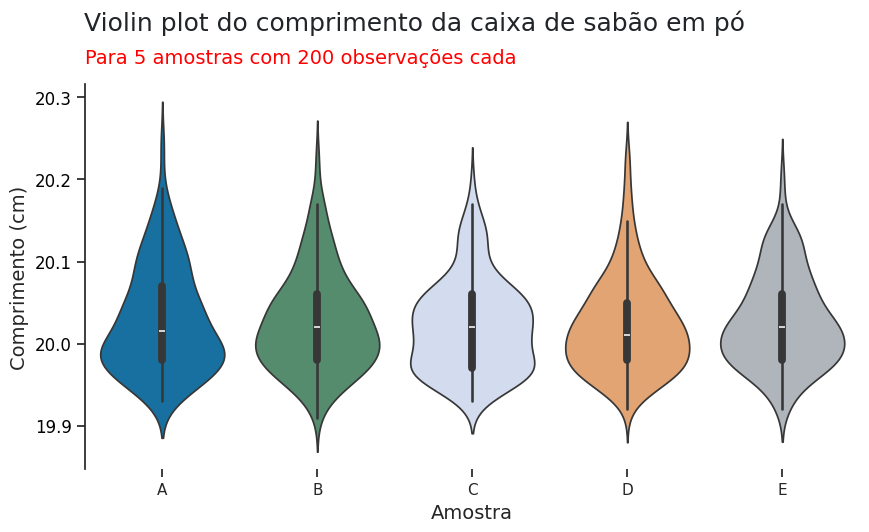

In [157]:
## Configurando o gráfico com parâmetros que potencializam a visualização dos dados

# Importando as bibliotecas
import matplotlib.pyplot as plt
import seaborn as sns

# Área do gráfico e tema da visualização
fig, axs = plt.subplots(figsize=(10,5))
sns.set_theme(style="ticks")

ax = sns.violinplot(data = df_medidas, x = "amostra", y = "comprimento", palette = [AZUL2, VERDE1, AZUL5, LARANJA1, CINZA3])

# Personalizando o gráfico
plt.suptitle('Violin plot do comprimento da caixa de sabão em pó', size=18, color=CINZA1, ha = 'right', x = 0.785, y = 1.03)
plt.title('Para 5 amostras com 200 observações cada', fontsize=14, color='red', pad = 15, loc = "left")
ax.set_xlabel('Amostra', fontsize = 14)
ax.set_ylabel('Comprimento (cm)', fontsize = 14)
ax.yaxis.set_tick_params(labelsize=12, labelcolor = 'black')
sns.despine(bottom=True)

plt.show()

# Duas variáveis ao mesmo tempo. (Gráficos de dispesão)

* Pergunta 1: Como estão dispostas as medidas de comprimento e altura da amostra?

In [160]:
df_a = df_medidas.query("amostra == 'A'")[['comprimento', 'altura']]
df_a.head()

,comprimento,altura
0,20.11,14.89
1,20.13,14.86
2,19.99,15.01
3,20.06,14.93
4,19.99,15.01


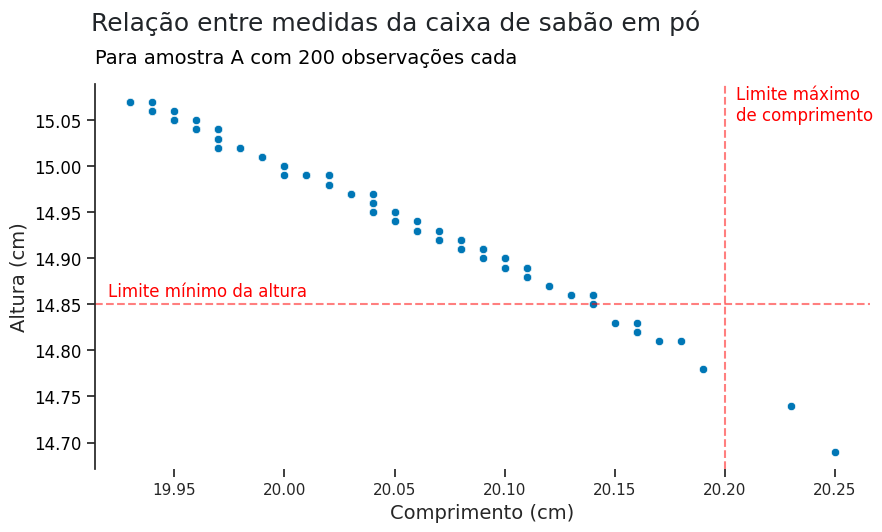

In [184]:
def graficos_dispersao(map_cores: list=[AZUL2], pct: float=0.01):

  import matplotlib.pyplot as plt
  import seaborn as sns

  # Área do gráfico e tema da visualização
  fig, axs = plt.subplots(figsize=(10,5))
  sns.set_theme(style="ticks")

  ax = sns.scatterplot(data = df_a, x = "comprimento", y = "altura", color = map_cores)

  # Personalizando o gráfico
  plt.suptitle('Relação entre medidas da caixa de sabão em pó', size=18, color=CINZA1, ha = 'right', x = 0.73, y = 1.03)
  plt.title('Para amostra A com 200 observações cada', fontsize=14, color='black', pad = 15, loc = "left")
  ax.set_xlabel('Comprimento (cm)', fontsize = 14)
  ax.set_ylabel('Altura (cm)', fontsize = 14)
  ax.yaxis.set_tick_params(labelsize=12, labelcolor = 'black')
  sns.despine(bottom=True)

  # Desenhando a linha horizontal com o límite mínimo de altura desejado
  ax.text(19.92, 14.855, 'Limite mínimo da altura', fontsize=12, color = 'red', va = "bottom")
  plt.axhline(y = 15 * (1 - pct), xmin = 0, xmax = df_a["comprimento"].max(), color = 'red', linestyle='--', alpha=0.5)

  # Desenhando a linha vertical com o límite máximo de comprimento desejado
  ax.text(20.205, 15.05, 'Limite máximo\nde comprimento', fontsize=12, color = 'red', ha="left", )
  plt.axvline(x = 20 * (1 + pct), color = 'red', linestyle='--', alpha=0.5)
  return ax

ax = graficos_dispersao()

### Exemplo de gráfico de distribuição para notas de corte da escola

In [185]:
import pandas as pd

notas_pds = [75, 69, 76, 85, 68, 68, 86, 78, 65, 75, 65, 65, 72, 51, 53, 64, 60,
             73, 61, 56, 85, 68, 71, 56, 65, 71, 58, 74, 64, 67, 64, 88, 70, 59,
             78, 58, 72, 50, 57, 72, 77, 72, 69, 67, 55, 63, 65, 81, 73, 52, 73,
             66, 63, 76, 80, 79, 62, 67, 73, 80, 65, 68, 59, 58, 78, 84, 69, 80,
             74, 64, 74, 85, 70, 86, 44, 78, 71, 67, 71, 50, 68, 74, 85, 65, 62,
             65, 79, 73, 65, 75, 71, 80, 63, 67, 66, 55, 73, 73, 70, 68]

notas_dataviz = [68, 67, 75, 81, 67, 70, 95, 79, 67, 75, 56, 65, 73, 63, 52, 66, 60,
                 67, 67, 60, 89, 63, 78, 49, 67, 82, 54, 71, 64, 65, 56, 89, 65, 62,
                 74, 66, 68, 49, 61, 66, 79, 78, 61, 68, 57, 67, 59, 74, 76, 54, 74,
                 68, 60, 77, 82, 76, 71, 69, 67, 83, 60, 72, 65, 54, 83, 86, 73, 90,
                 72, 60, 69, 81, 69, 87, 45, 82, 71, 74, 70, 64, 71, 69, 79, 67, 61,
                 69, 82, 73, 60, 68, 69, 84, 64, 60, 67, 57, 69, 73, 70, 62]

data = pd.DataFrame({'notas_pds': notas_pds, 'notas_dataviz': notas_dataviz})

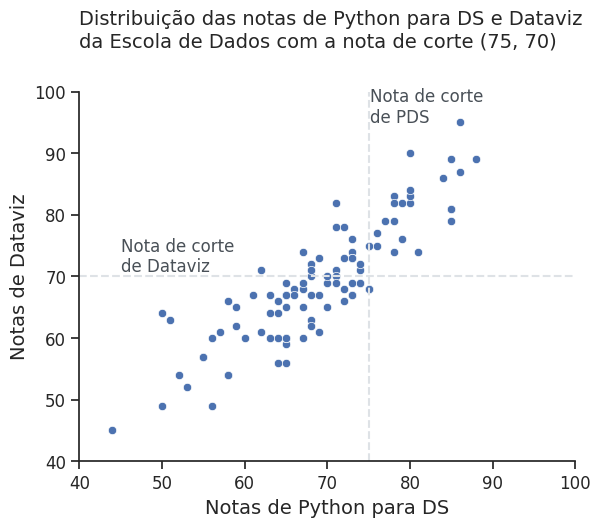

In [187]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotando o gráfico de dispersão
ax = sns.scatterplot(data=data, x='notas_pds', y='notas_dataviz')

# Personalizando o gráfico
ax.set_title('Distribuição das notas de Python para DS e Dataviz \nda Escola de Dados com a nota de corte (75, 70)', size=14, ha = 'left', x = 0, y = 1.1)
ax.set_xlabel('Notas de Python para DS',  fontsize = 14)
ax.set_ylabel('Notas de Dataviz', fontsize = 14)
ax.xaxis.set_tick_params(labelsize=12)
ax.yaxis.set_tick_params(labelsize=12)
ax.set_xlim(40, 100)
ax.set_ylim(40, 100)
sns.despine()

# Desenhando as linhas de corte para as notas mínimas das duas disciplinas e o texto sobre elas
cores = ["#dee2e6", "#495057"]

ax.text(75.1, 95, 'Nota de corte \nde PDS', fontsize=12, color = cores[1], ha="left")
plt.axvline(x = 75, color = cores[0], linestyle='--')

ax.text(45, 70.1, 'Nota de corte \nde Dataviz', fontsize=12, color = cores[1], va = "bottom")
plt.axhline(y = 70, color = cores[0], linestyle='--')

plt.show()

### implementando o gráfico

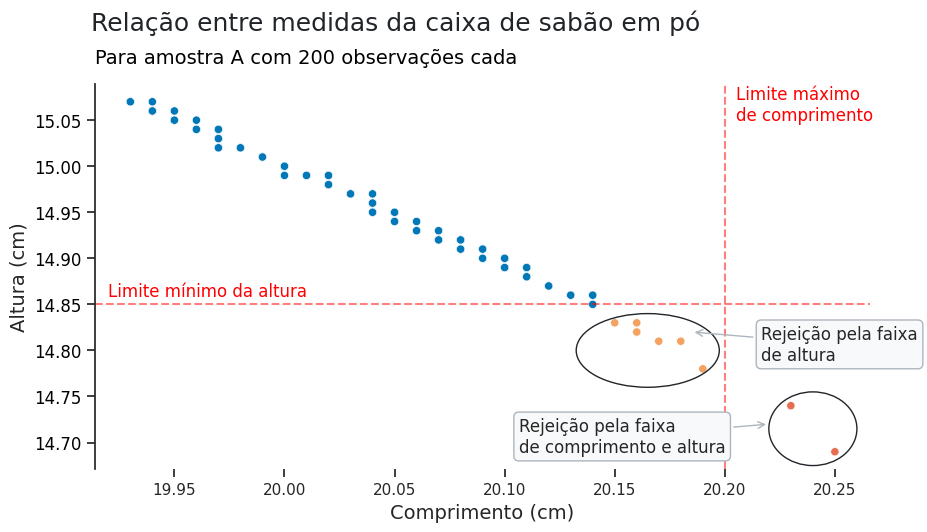

In [194]:
# Importando as bibliotecas
from matplotlib.patches import Ellipse
import numpy as np

# Definindo as cores do gráfico
cores = [VERMELHO1, LARANJA1, AZUL2]

# Gerando o gráfico de dispersão e rejeitando os valores fora da faixa requisitada (1%)
pct = 0.01
rejeita_comp = [True if (c > 20*(1+pct) or c < 20*(1-pct)) else False for c in df_a["comprimento"]]
rejeita_alt = [True if (a > 15*(1+pct) or a < 15*(1-pct)) else False for a in df_a["altura"]]
map_cores = np.where(rejeita_comp, cores[0], np.where(rejeita_alt, cores[1], cores[2]))
ax = graficos_dispersao(map_cores, pct)

# Selecionando as áreas de rejeição
rej_comp = Ellipse((20.165, 14.80), width = 0.065, height = 0.08, color=CINZA1, fill=False)
rej_alt = Ellipse((20.24, 14.715), width = 0.04, height = 0.08, color=CINZA1, fill=False)
ax.add_patch(rej_comp)
ax.add_patch(rej_alt)

ax.annotate("Rejeição pela faixa\nde altura", xy=(20.185, 14.82), xycoords='data',
            bbox=dict(boxstyle="round", fc=CINZA5, ec=CINZA3),
            xytext=(50, -20), textcoords='offset points',
            arrowprops=dict(arrowstyle="->", color=CINZA3))

ax.annotate("Rejeição pela faixa\nde comprimento e altura", xy=(20.22, 14.72), xycoords='data',
             bbox=dict(boxstyle="round", fc=CINZA5, ec=CINZA3),
             xytext=(-180, -20), textcoords='offset points',
             arrowprops=dict(arrowstyle="->", color=CINZA3))

fig = ax.get_figure()

### Desafio AULA 5

* Desafio 1: Baixe a base de dados com as notas das turmas de Data Visualization e crie o violinplot, buscando interpretar as diferenças entre cada uma delas e documentando os seus achados. Sinta-se livre para adicionar alguns dos recursos que aprendemos ao longo do curso, como anotações, textos e figuras.

* Desafio 2: Crie o gráfico de dispersão que distribua as medidas de comprimento e largura da amostra B. Desenhe no gráfico as linhas de rejeição para os itens em que o valor de comprimento e largura seja acima de 2% ou abaixo do valor de 20 cm e 5 cm, respectivamente.

# Desafio 1

In [218]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

notas = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Avançando em Data Science com Python/Dados/notas.csv")
notas.head()

,Turma,Nota
0,Turma 1,79
1,Turma 1,73
2,Turma 1,80
3,Turma 1,88
4,Turma 1,72


<ipython-input-219-06cb01a95a95>:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




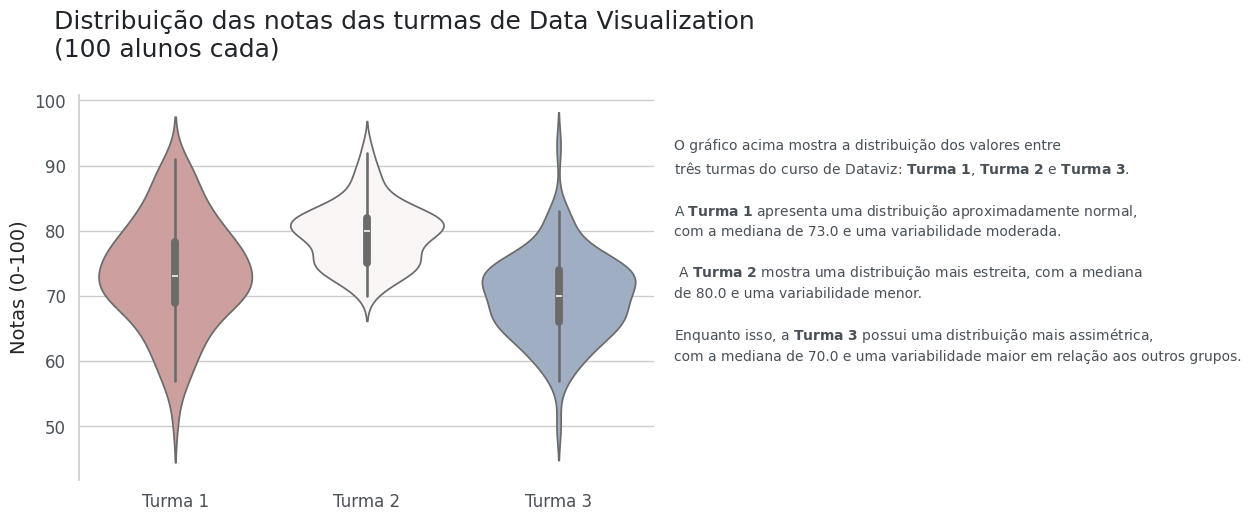

In [219]:
# Área do gráfico e tema da visualização
fig, ax = plt.subplots(figsize=(10,5))
fig.subplots_adjust(right = 0.7)
sns.set_theme(style="whitegrid")

# Gerando o violinplot das notas
ax = sns.violinplot(data = notas, x = "Turma", y = "Nota", palette = "vlag_r")

# Personalizando o gráfico
plt.suptitle('Distribuição das notas das turmas de Data Visualization\n(100 alunos cada)', size=18, color=CINZA1, ha = 'left', x = 0.1, y = 1.05)
ax.set_xlabel('')
ax.set_ylabel('Notas (0-100)', fontsize = 14)
ax.xaxis.set_tick_params(labelsize=12, labelcolor = CINZA2)
ax.yaxis.set_tick_params(labelsize=12, labelcolor = CINZA2)
sns.despine(bottom=True)

# Criando uma lista com as medianas de cada turma
mediana = []
for i in range(1,4):
  mediana.append(notas.query(f"Turma == 'Turma {i}'").Nota.median())

# Texto explicativo
ax.text(2.6, 60,
         'O gráfico acima mostra a distribuição dos valores entre\n'
         'três turmas do curso de Dataviz: $\\bf{Turma\ 1}$, $\\bf{Turma\ 2}$ e $\\bf{Turma\ 3}$.\n\n'
         'A $\\bf{Turma\ 1}$ apresenta uma distribuição aproximadamente normal,\n'
         f'com a mediana de {mediana[0]} e uma variabilidade moderada.\n\n'
         ' A $\\bf{Turma\ 2}$ mostra uma distribuição mais estreita, com a mediana\n'
         f'de {mediana[1]} e uma variabilidade menor.\n\n'
         'Enquanto isso, a $\\bf{Turma\ 3}$ possui uma distribuição mais assimétrica,\n'
         f'com a mediana de {mediana[2]} e uma variabilidade maior em relação aos outros grupos.',
         fontsize=10, linespacing=1.45, color=CINZA2)

plt.show()

# Desafio 2

In [220]:
# Importando a base de dados dos volumes de um amaciante em 1000 amostras realizadas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_medidas = pd.read_csv("https://raw.githubusercontent.com/afonsosr2/dataviz-graficos/master/dados/medidas_sabao_em_po.csv")
df_b = df_medidas.query('amostra == "B"')[["comprimento", "largura"]]

df_b.head()

,comprimento,largura
200,19.97,5.10
201,20.13,4.94
202,20.12,4.95
203,20.04,4.96
204,19.97,4.98


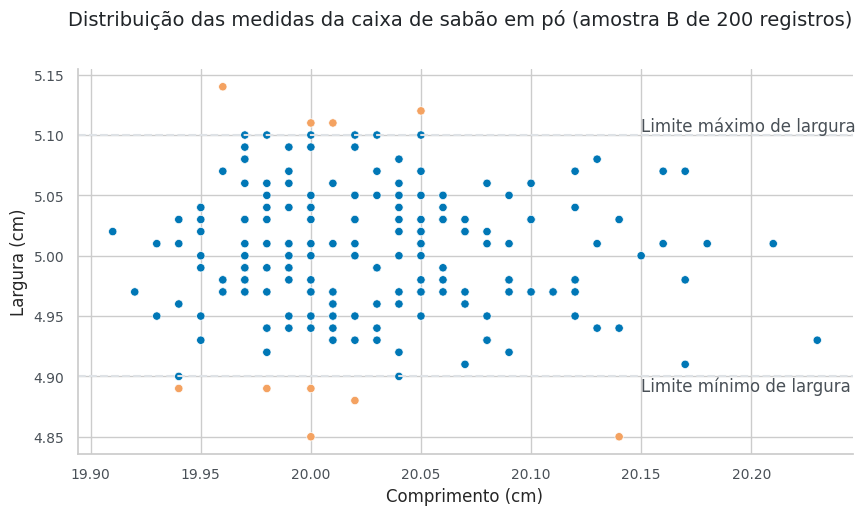

In [221]:
# Área do gráfico e tema da visualização
fig, ax = plt.subplots(figsize=(10,5))
sns.set_theme(style="white")

# Definindo as cores do gráfico e a porcentagem de rejeição
cores = [VERMELHO1, LARANJA1, AZUL2]
pct = 0.02

# Mapeando as cores para a faixa requisitada (2%)
rejeita_comp = [True if (c > 20*(1+pct) or c < 20*(1-pct)) else False for c in df_b["comprimento"]]
rejeita_larg = [True if (a > 5*(1+pct) or a < 5*(1-pct)) else False for a in df_b["largura"]]
map_cores = np.where(rejeita_comp, cores[0], np.where(rejeita_larg, cores[1], cores[2]))

# Gerando o gráfico de dispersão
ax = sns.scatterplot(data = df_b, x="comprimento", y = "largura", color = map_cores)

# Personalizando o gráfico
plt.suptitle('Distribuição das medidas da caixa de sabão em pó (amostra B de 200 registros)', size=14, color=CINZA1, ha = 'right', x = 0.9, y = 1)
ax.set_xlabel('Comprimento (cm)', fontsize = 12)
ax.set_ylabel('Largura (cm)', fontsize = 12)
ax.yaxis.set_tick_params(labelsize=10, labelcolor = CINZA2)
ax.xaxis.set_tick_params(labelsize=10, labelcolor = CINZA2)
sns.despine()

### Desenhando as linhas verticais com os limites mínimos e máximo de largura desejada
ax.text(20.15, 5.1, 'Limite máximo de largura', fontsize=12, color = CINZA2, ha="left", va = "bottom")
plt.axhline(y = 5 * (1 + pct), color = CINZA4, linestyle='--')
ax.text(20.15, 4.9, 'Limite mínimo de largura', fontsize=12, color = CINZA2, ha="left", va = "top")
plt.axhline(y = 5 * (1 - pct), color = CINZA4, linestyle='--')

plt.show()